<a href="https://colab.research.google.com/github/SilasDetering/SilasBA/blob/main/Silas_BA_Graphen.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files, drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit
from sklearn.linear_model import LinearRegression

In [2]:
# Google Drive verbinden
drive.mount('/content/drive')

Mounted at /content/drive


In [28]:
# Datei aus Google Drive laden
file_name = '/content/drive/MyDrive/Colab Notebooks/Messung1401-1.xlsx'

# 1.0 Raw RSSI and Kalmanfiltered RSSI für bestimmte Distanz (old)

In [ ]:
df = pd.read_excel(file_name, header=1)
df = df[['TimeStep', 'RAW', 'KALMAN']]

# Reale Distanz als konstante festlegen
real_distance = 0.5

# Graphen erstellen
plt.figure(figsize=(12, 6))

# Plot für RSSI
plt.plot(df.index, df['RAW'], label='Raw RSSI', linestyle='-', color='gray')

# Plot für gefilterten RSSI
plt.plot(df.index, df['KALMAN'], label='Filtered RSSI', linestyle='--', color='blue')

plt.ylabel('RSSI (dBm)')
plt.xlabel('Timesteps')

# Zweite Y-Achse für die Distanz
# dist_ax = plt.gca().twinx()
# dist_ax.plot(df.index, df['Distance'], label='Distance', color='green', linestyle='--')

# Reale Distanz als konstante Linie hinzufügen
# dist_ax.axhline(y=real_distance, color='red', linestyle=':', label='Real Distance')

# Achsentitel und Beschriftungen setzen
# dist_ax.set_ylabel('Distance (m)')

plt.legend()
plt.grid()
plt.title('raw RSSI and kalmanfiltered RSSI für ' + str(real_distance) + 'm')

plt.show()


NameError: name 'file_name' is not defined

# 1.1 Hig Fluctuation Filter für bestimmte Distanz (old)

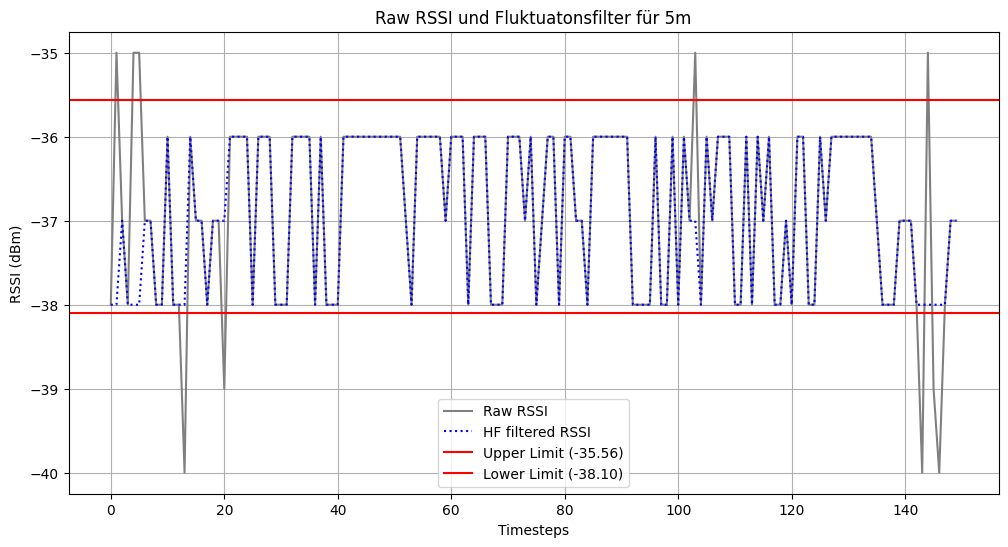

In [ ]:
df = pd.read_excel(file_name, header=1)
df = df[['TimeStep', 'RAW', 'KALMAN']]

# Berechnung des Mittelwerts und der Standardabweichung der RSSI-Werte
mean_rssi = df['RAW'].mean()
std_rssi = df['RAW'].std()

# Berechnung der Limits (Fluktuationsfilter)
upper_limit = mean_rssi + (1.2 * std_rssi)
lower_limit = mean_rssi - (1.2 * std_rssi)

# Filtern der RSSI-Werte innerhalb der Limits
df['Filtered'] = df['RAW'].where((df['RAW'] <= upper_limit) & (df['RAW'] >= lower_limit))

# Fehlende Werte (NaN) mit vorwärts-/rückwärtsgerichteter Interpolation auffüllen
df['Filtered'] = df['Filtered'].ffill().bfill()

# Graphen erstellen
plt.figure(figsize=(12, 6))

# Plot für RSSI
plt.plot(df.index, df['RAW'], label='Raw RSSI', linestyle='-', color='gray')

# Plot für gefilterten RSSI
plt.plot(df.index, df['Filtered'], label='HF filtered RSSI', linestyle=':', color='blue')

# Plot der Upper Limit und Lower Limit Linien
plt.axhline(y=upper_limit, color='red', linestyle='-', label=f'Upper Limit ({upper_limit:.2f})')
plt.axhline(y=lower_limit, color='red', linestyle='-', label=f'Lower Limit ({lower_limit:.2f})')

plt.ylabel('RSSI (dBm)')
plt.xlabel('Timesteps')

# Legenden anpassen
plt.legend()
plt.grid()
plt.title('Raw RSSI und Fluktuatonsfilter für ' + str(real_distance) + 'm')

plt.show()


# 2.0 RSSI ohne Filter für mehrere Distanzen
*mit Distance Path Loss n, m Parameter kalibrierung*

Optimierte Parameter: n = 2.19, a = -44.74
Filter: KALMAN


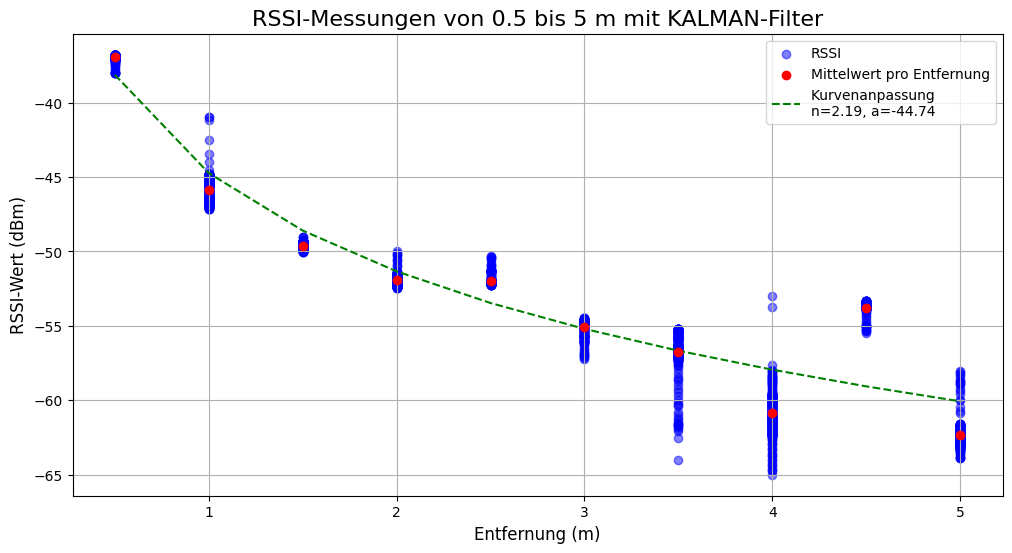

In [37]:
# Excel-Datei einlesen
df = pd.read_excel(file_name, header=1)  # Die zweite Zeile enthält die Spaltenüberschriften
distances = pd.read_excel(file_name, header=None).iloc[0].dropna().unique()  # Die erste Zeile enthält die Distanzen

num_filters = 5  # Anzahl der Filter (RAW, FLUCT, KALMAN, MEDIAN, MAX)
mean_rssi_per_distance = {}
selected_filter = 'KALMAN'  # Filter auswählen
sigma_shadow = 14.1

# Distance Path-Loss Model
def rssi_model(distance, n, a):
    return -10 * n * np.log10(distance) + a

# Graphen erstellen
plt.figure(figsize=(12, 6))

for i, dist in enumerate(distances):
    # Spalten für die aktuelle Distanz extrahieren
    start_col = i * (num_filters + 1)  # Startspalte für diese Distanz
    cols = df.columns[start_col : start_col + (num_filters + 1)]  # Zeitsäule + Filterspalten

    # Sub-DataFrame erstellen
    dist_df = df[cols].rename(columns={
        cols[0]: 'TimeStep',
        cols[1]: 'RAW',
        cols[2]: 'FLUCT',
        cols[3]: 'KALMAN',
        cols[4]: 'MEDIAN',
        cols[5]: 'MAX'
    })

    # NaN-Werte interpolieren
    dist_df = dist_df.interpolate()

    # Mittelwert der RSSI-Werte für jede Entfernung berechnen
    mean_rssi_per_distance[dist] = dist_df[selected_filter].mean()

    # Einzelne RSSI-Werte für diese Distanz darstellen
    plt.scatter([dist] * len(dist_df), dist_df[selected_filter], color='blue', alpha=0.5, label=f'RSSI' if i == 0 else "")

# Curve-Fit durchführen
distances = list(mean_rssi_per_distance.keys())
mean_rssi_values = list(mean_rssi_per_distance.values())

# DPL-Model
popt, pcov = curve_fit(rssi_model, distances, mean_rssi_values)
n, a = popt
print(f"Optimierte Parameter: n = {n:.2f}, a = {a:.2f}")

# Selected Filter ausgeben:
print(f"Filter: {selected_filter}")

# Fit-Daten berechnen
fitted_rssi = rssi_model(np.array(distances), n, a)

# Mittelwert als Punkte für jede Entfernung zeichnen
plt.scatter(distances, mean_rssi_values,
            color='red', label='Mittelwert', zorder=5)

# Angepasste Kurve hinzufügen
plt.plot(distances, fitted_rssi,
         color='green', linestyle='--',
         label=f'Kurvenanpassung \nn={n:.2f}, a={a:.2f}')

# Titel und Achsenbeschriftungen hinzufügen
if selected_filter == 'RAW':
  plt.title(f"RSSI-Messungen von {min(distances)} bis {max(distances)} m", fontsize=16)
else:
  plt.title(f"RSSI-Messungen von {min(distances)} bis {max(distances)} m mit {selected_filter}-Filter", fontsize=16)

plt.xlabel("Entfernung (m)", fontsize=12)
plt.ylabel("RSSI-Wert (dBm)", fontsize=12)

# Legende hinzufügen
plt.legend()

# Raster aktivieren
plt.grid(True)

# Plot anzeigen
plt.show()

# 2.1 RSSI mit Hard Fluctuation Filter für mehrere Distanzen
*mit Distance Path Loss n, m Parameter kalibrierung*

Optimierte Parameter: n = 2.19, a = -44.72


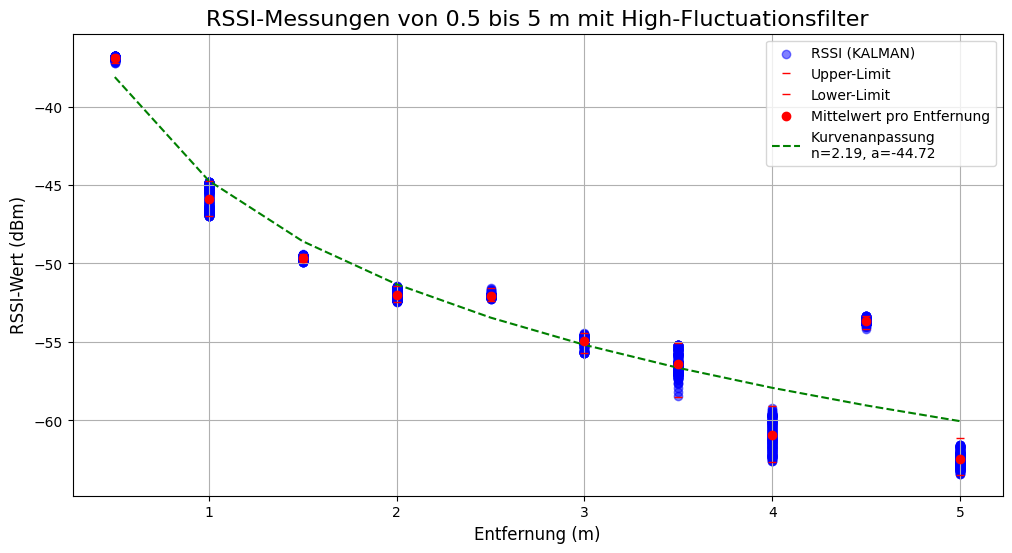

In [30]:
# Excel-Datei einlesen
df = pd.read_excel(file_name, header=1)  # Die zweite Zeile enthält die Spaltenüberschriften
distances = pd.read_excel(file_name, header=None).iloc[0].dropna().unique()  # Die erste Zeile enthält die Distanzen

num_filters = 5  # Anzahl der Filter (RAW, FLUCT, KALMAN, MEDIAN, MAX)
selected_filter = 'KALMAN'  # Filter auswählen

mean_rssi_per_distance = {}
std_rssi_per_distance = {}

# Distance Path-Loss Model definieren
def rssi_model(distance, n, a):
    return -10 * n * np.log10(distance) + a

# Graphen erstellen
plt.figure(figsize=(12, 6))

for i, dist in enumerate(distances):
    # Spalten für die aktuelle Distanz extrahieren
    start_col = i * (num_filters + 1)  # Startspalte für diese Distanz
    cols = df.columns[start_col : start_col + (num_filters + 1)]  # Zeitsäule + Filterspalten

    # Sub-DataFrame erstellen
    dist_df = df[cols].rename(columns={
        cols[0]: 'TimeStep',
        cols[1]: 'RAW',
        cols[2]: 'FLUCT',
        cols[3]: 'KALMAN',
        cols[4]: 'MEDIAN',
        cols[5]: 'MAX'
    })

    # NaN-Werte interpolieren
    dist_df = dist_df.interpolate()

    # Mittelwert und Standardabweichung berechnen
    mean_rssi_per_distance[dist] = dist_df[selected_filter].mean()
    std_rssi_per_distance[dist] = dist_df[selected_filter].std()

    # Upper Limit und Lower Limit bestimmen
    upper_limit = mean_rssi_per_distance[dist] + (1.2 * std_rssi_per_distance[dist])
    lower_limit = mean_rssi_per_distance[dist] - (1.2 * std_rssi_per_distance[dist])

    # Daten Filtern
    dist_df['Filtered'] = dist_df[selected_filter].where((dist_df[selected_filter] <= upper_limit) & (dist_df[selected_filter] >= lower_limit))

    # Mittelwert neu bestimmen
    mean_rssi_per_distance[dist] = dist_df['Filtered'].mean()

    # Einzelne RSSI-Werte für diese Distanz darstellen
    plt.scatter([dist] * len(dist_df), dist_df['Filtered'], color='blue', alpha=0.5, label=f'RSSI ({selected_filter})' if i == 0 else "")

    # Upper- und Lowerlimit zeichnen
    plt.plot(dist, upper_limit, color='red', linestyle='None', marker='_', label=f'Upper-Limit' if i == 0 else "")
    plt.plot(dist, lower_limit, color='red', linestyle='None', marker='_', label=f'Lower-Limit' if i == 0 else "")

# Curve-Fit durchführen
popt, pcov = curve_fit(rssi_model, list(mean_rssi_per_distance.keys()), list(mean_rssi_per_distance.values()))

# Optimierte Parameter
n, a = popt
print(f"Optimierte Parameter: n = {n:.2f}, a = {a:.2f}")

# Fit-Daten berechnen
fitted_rssi = rssi_model(np.array(list(mean_rssi_per_distance.keys())), n, a)

# Mittelwert als Punkte für jede Entfernung zeichnen
plt.scatter(list(mean_rssi_per_distance.keys()), list(mean_rssi_per_distance.values()),
            color='red', label='Mittelwert pro Entfernung', zorder=5)

# Angepasste Kurve hinzufügen
plt.plot(list(mean_rssi_per_distance.keys()), fitted_rssi,
         color='green', linestyle='--',
         label=f'Kurvenanpassung \nn={n:.2f}, a={a:.2f}')

# Titel und Achsenbeschriftungen hinzufügen
plt.title(f"RSSI-Messungen von {min(distances)} bis {max(distances)} m mit High-Fluctuationsfilter", fontsize=16)
plt.xlabel("Entfernung (m)", fontsize=12)
plt.ylabel("RSSI-Wert (dBm)", fontsize=12)

# Legende hinzufügen
plt.legend()

# Raster aktivieren
plt.grid(True)

# Plot anzeigen
plt.show()

# 3. Vergleich unterschiedliche RSSI Filter

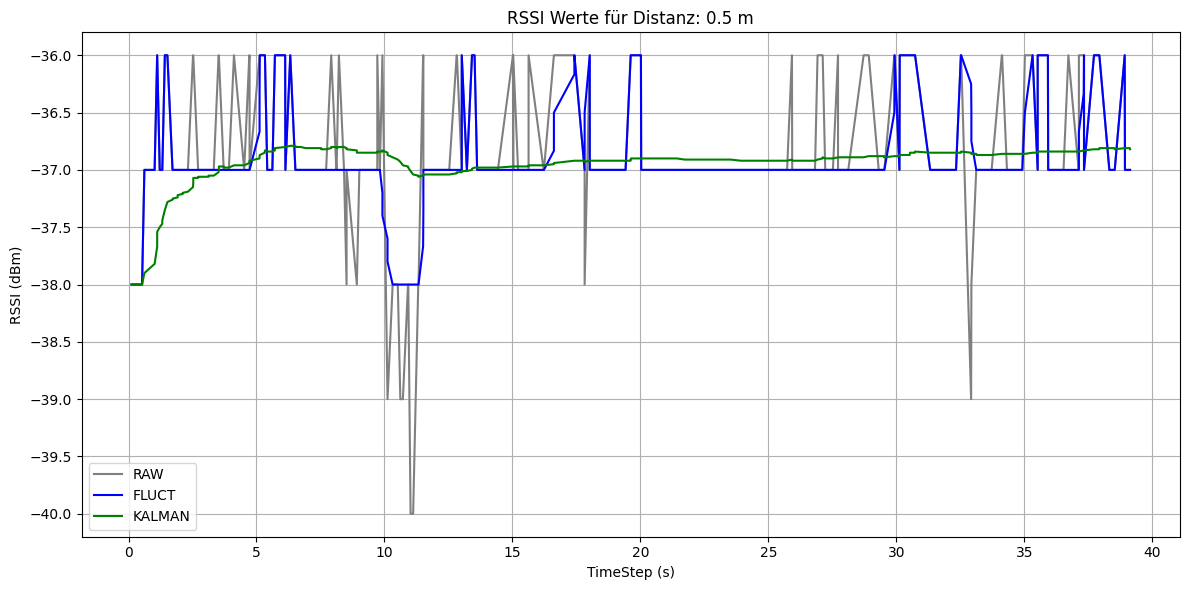

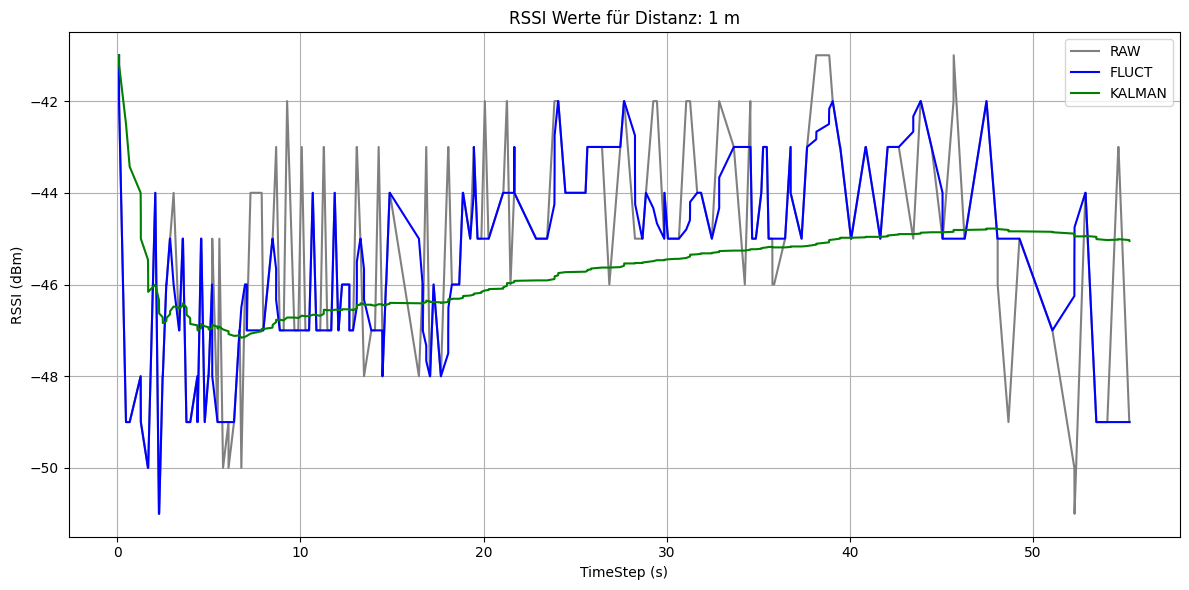

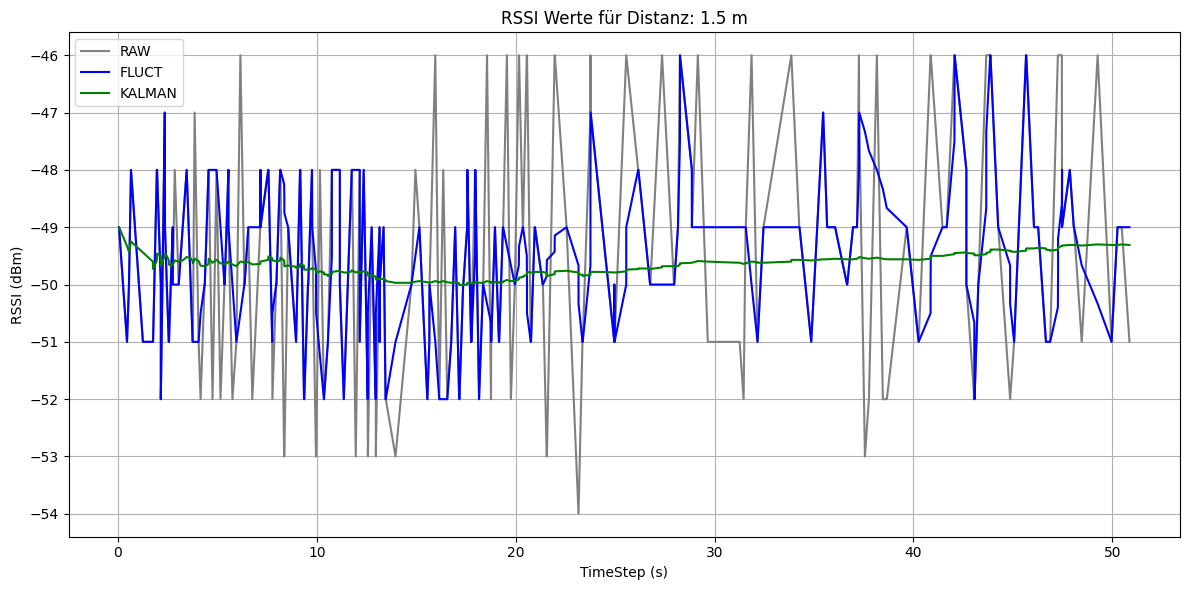

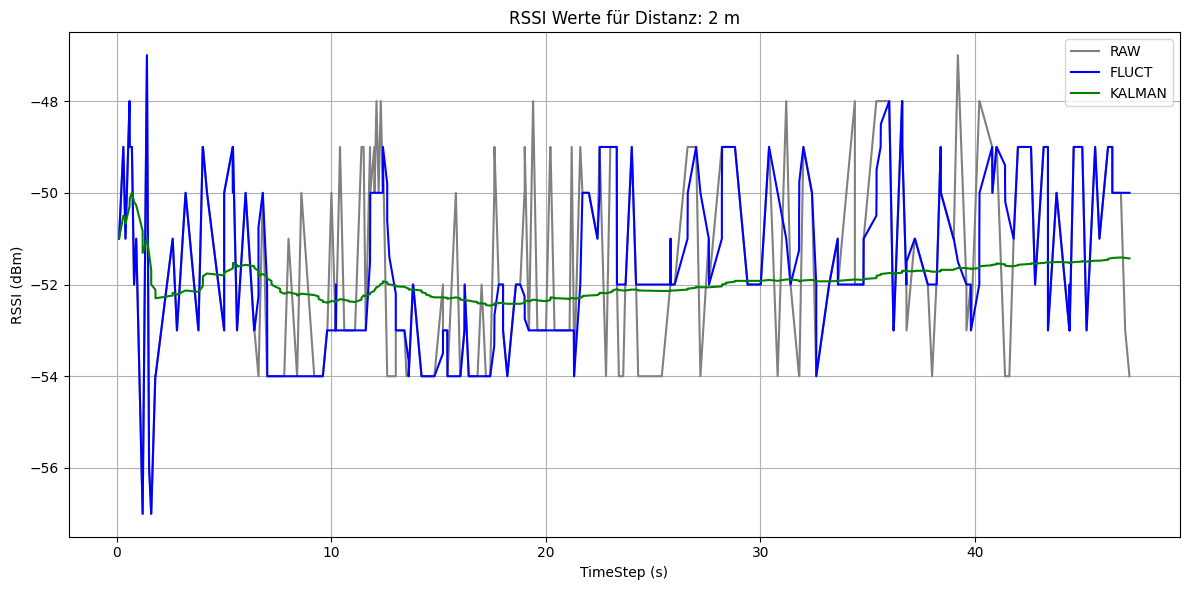

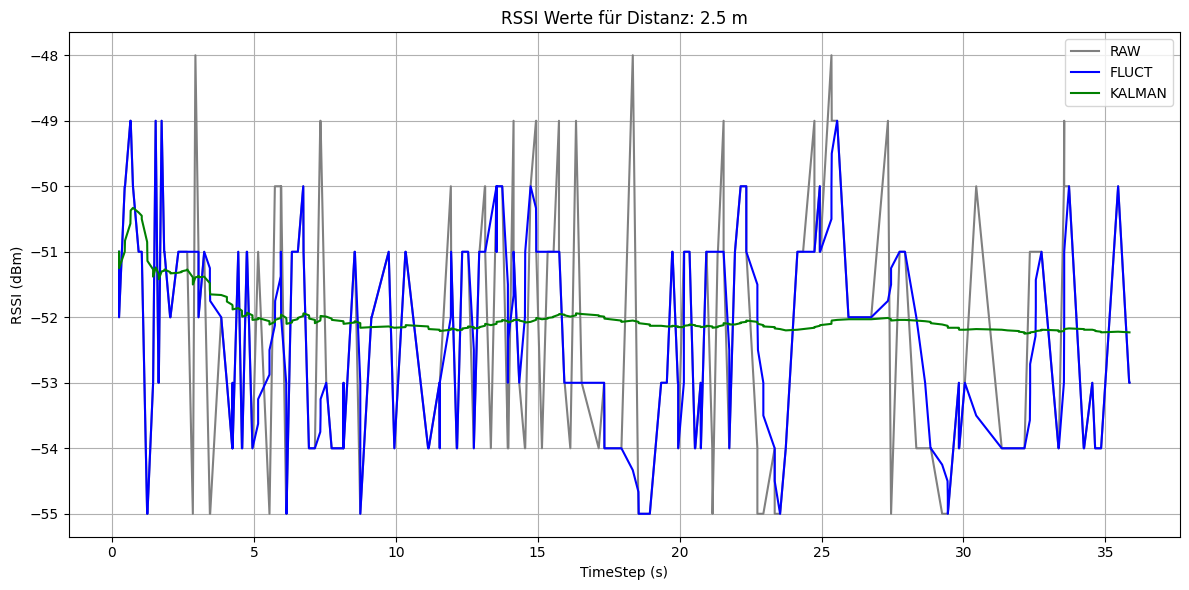

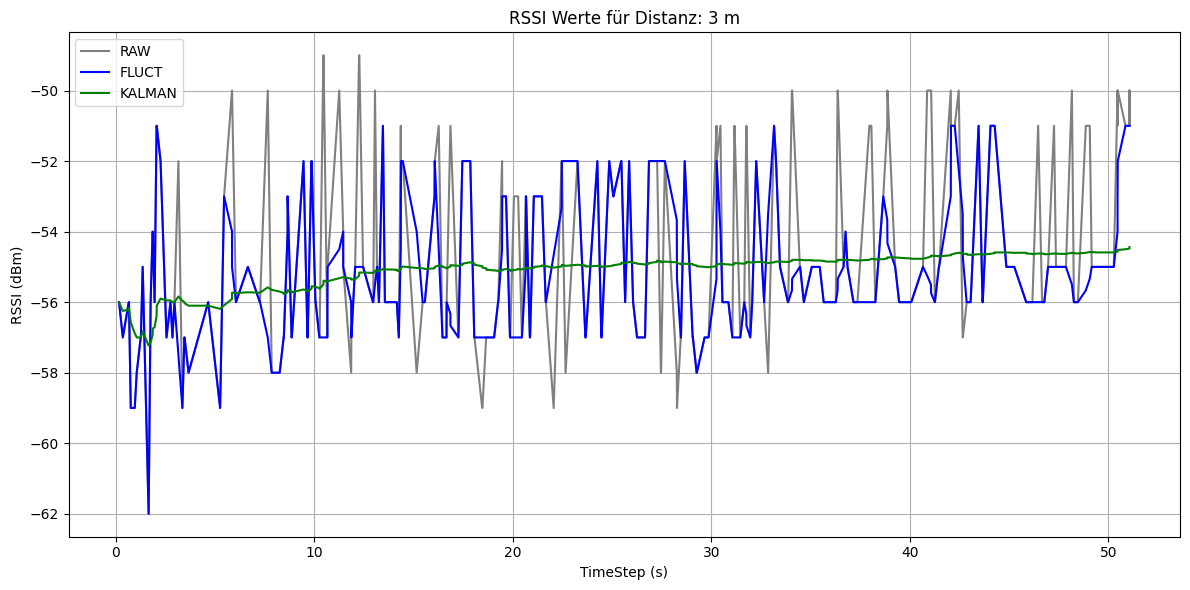

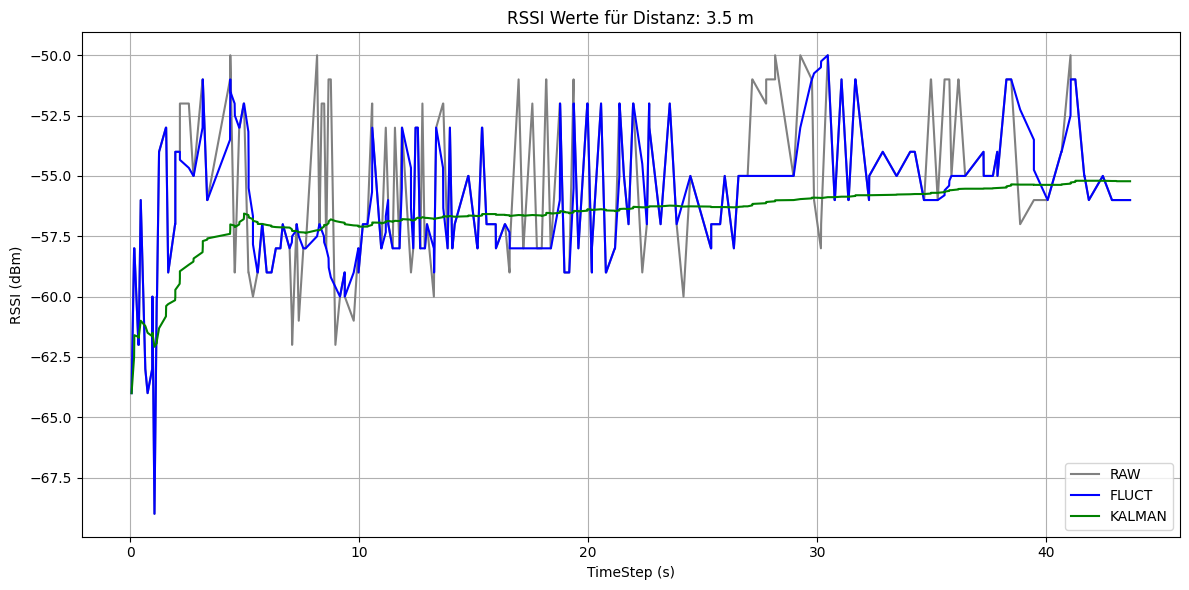

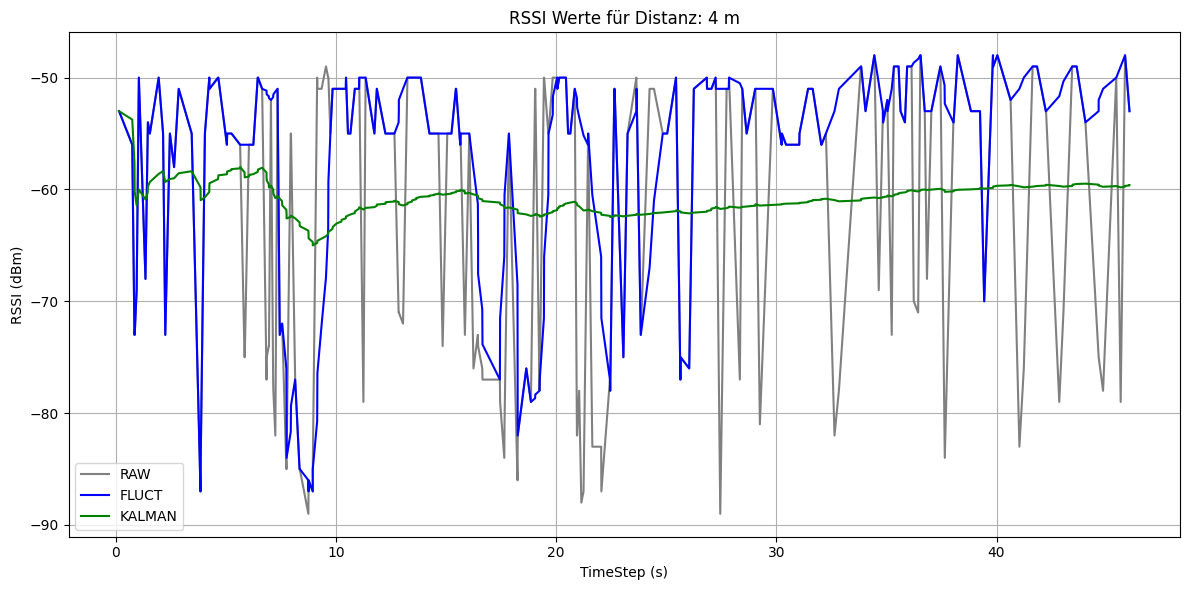

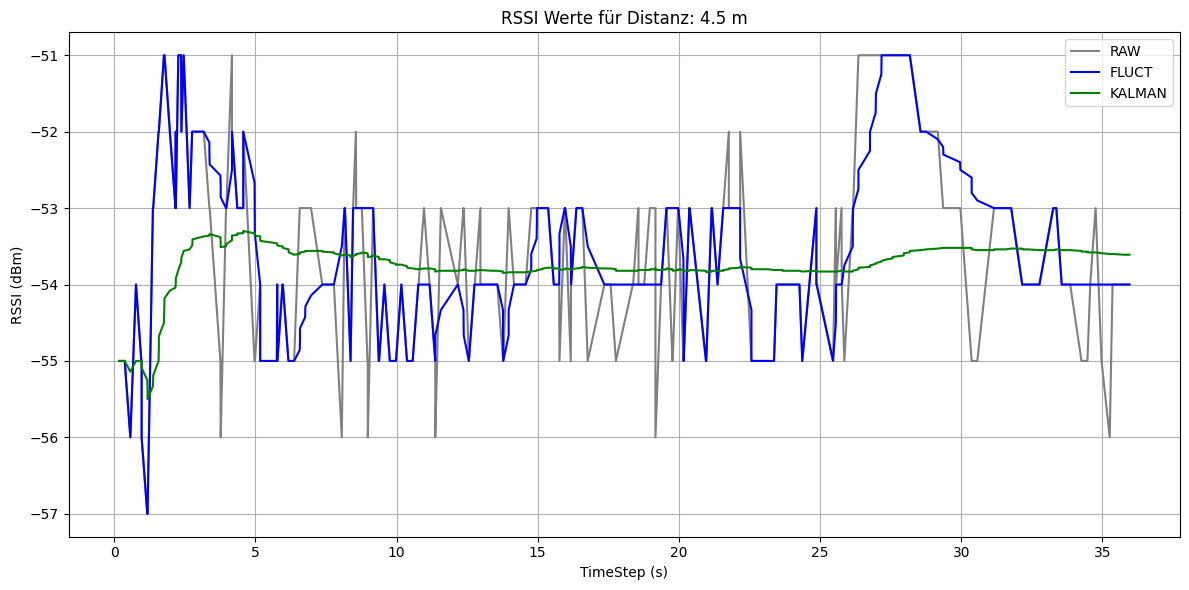

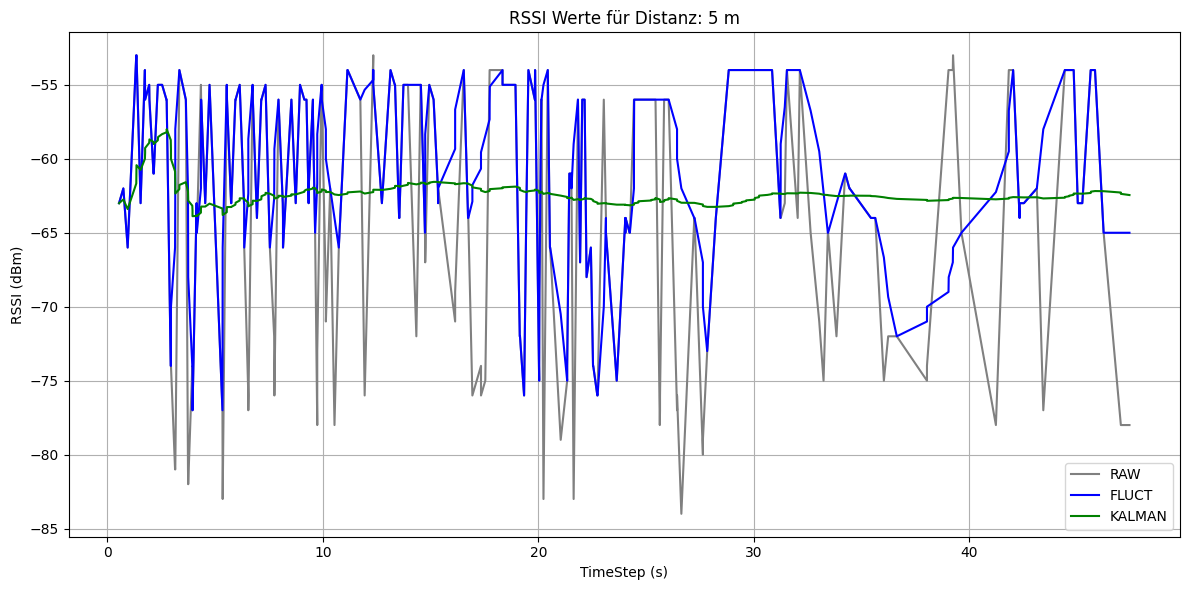

In [31]:
# Filter wählen:
display_filter = ['RAW','KALMAN', 'FLUCT'] # ['RAW','FLUCT','KALMAN','MEDIAN','MAX']

# Excel-Datei einlesen
df = pd.read_excel(file_name, header=1)  # Die zweite Zeile enthält die Spaltenüberschriften
distances = pd.read_excel(file_name, header=None).iloc[0].dropna().unique()  # Die erste Zeile enthält die Distanzen

num_filters = 5  # Anzahl der Filter (RAW, FLUCT, KALMAN, MEDIAN, MAX)

for i, dist in enumerate(distances):
    # Spalten für die aktuelle Distanz extrahieren
    start_col = i * (num_filters + 1)  # Startspalte für diese Distanz
    cols = df.columns[start_col : start_col + (num_filters + 1)]  # Zeitsäule + Filterspalten

    # Sub-DataFrame erstellen
    dist_df = df[cols].rename(columns={
        cols[0]: 'TimeStep',
        cols[1]: 'RAW',
        cols[2]: 'FLUCT',
        cols[3]: 'KALMAN',
        cols[4]: 'MEDIAN',
        cols[5]: 'MAX'
    })

    # NaN-Werte interpolieren
    dist_df = dist_df.interpolate()

    # Graphen erstellen
    plt.figure(figsize=(12, 6))

    if 'RAW' in display_filter:
        plt.plot(dist_df['TimeStep'], dist_df['RAW'], label='RAW', color='gray', linestyle='-')
    if 'FLUCT' in display_filter:
        plt.plot(dist_df['TimeStep'], dist_df['FLUCT'], label='FLUCT', color='blue', linestyle='-')
    if 'KALMAN' in display_filter:
        plt.plot(dist_df['TimeStep'], dist_df['KALMAN'], label='KALMAN', color='green', linestyle='-')
    if 'MEDIAN' in display_filter:
        plt.plot(dist_df['TimeStep'], dist_df['MEDIAN'], label='MEDIAN', color='red', linestyle='-')
    if 'MAX' in display_filter:
        plt.plot(dist_df['TimeStep'], dist_df['MAX'], label='MAX', color='orange', linestyle='-.')

    # Achsenbeschriftungen und Titel
    plt.ylabel('RSSI (dBm)')
    plt.xlabel('TimeStep (s)')
    plt.title(f'RSSI Werte für Distanz: {dist} m')
    plt.legend()
    plt.grid()
    plt.tight_layout()

    # Diagramm anzeigen
    plt.show()

# 3.1 Berechnete Distanzen für unterschiedliche Filter

In [ ]:
# Logarithmische Path Loss Funktion zur Berechnung der Distanz
def logarithmic_distance_path_loss(rssi, rssi_one_meter, disturbance_level, sigma):
    n = round(disturbance_level, 2)
    a = round(rssi_one_meter, 2)

    # Berechnung der Entfernung
    return 10**((a - rssi) / (10 * n))

In [ ]:
# Logarithmische Path Loss Funktion mit Shadowing zur Berechnung der Distanz
def logarithmic_distance_path_loss(rssi, rssi_one_meter, disturbance_level, sigma):
    n = round(disturbance_level, 2)
    a = round(rssi_one_meter, 2)
    X = np.random.normal(0, sigma)

    # Berechnung der Entfernung
    return 10**((a - rssi - X) / (10 * n))

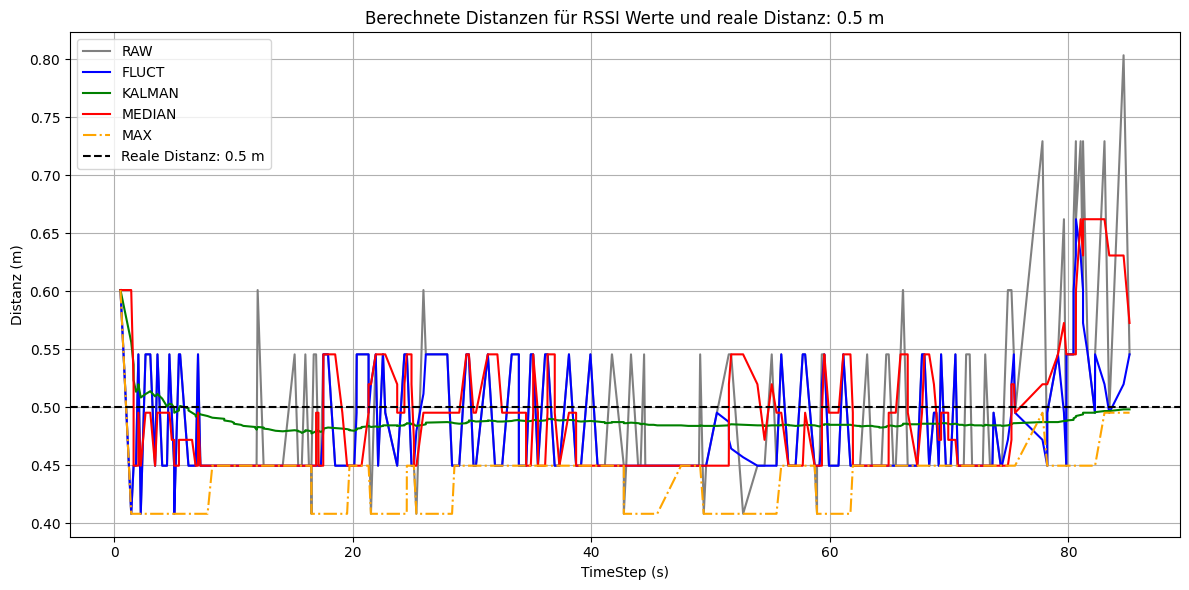

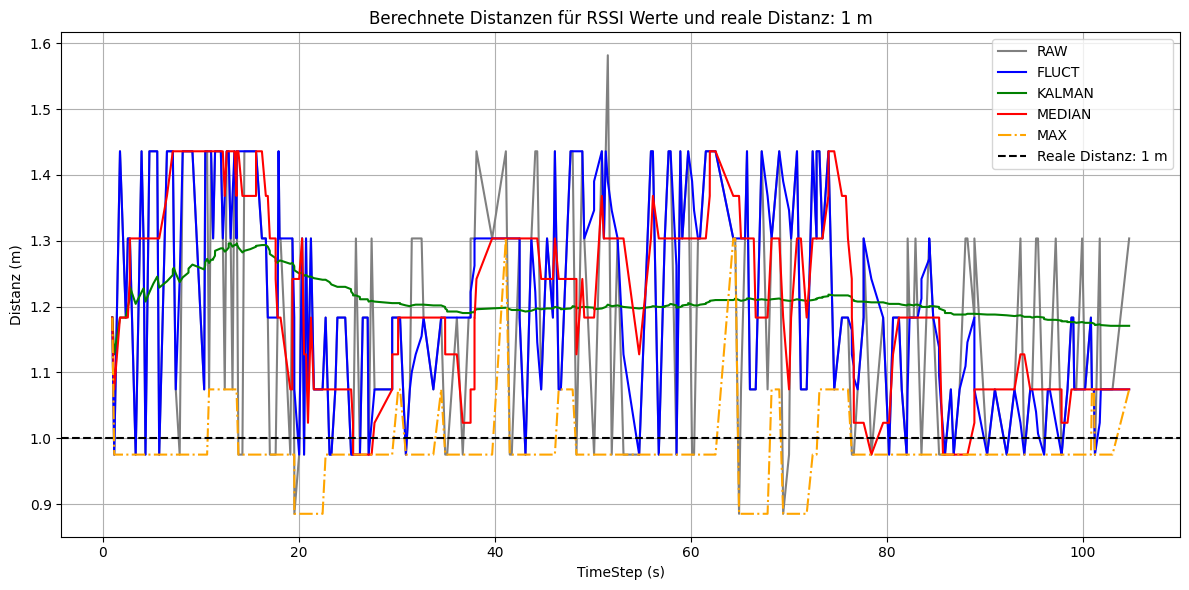

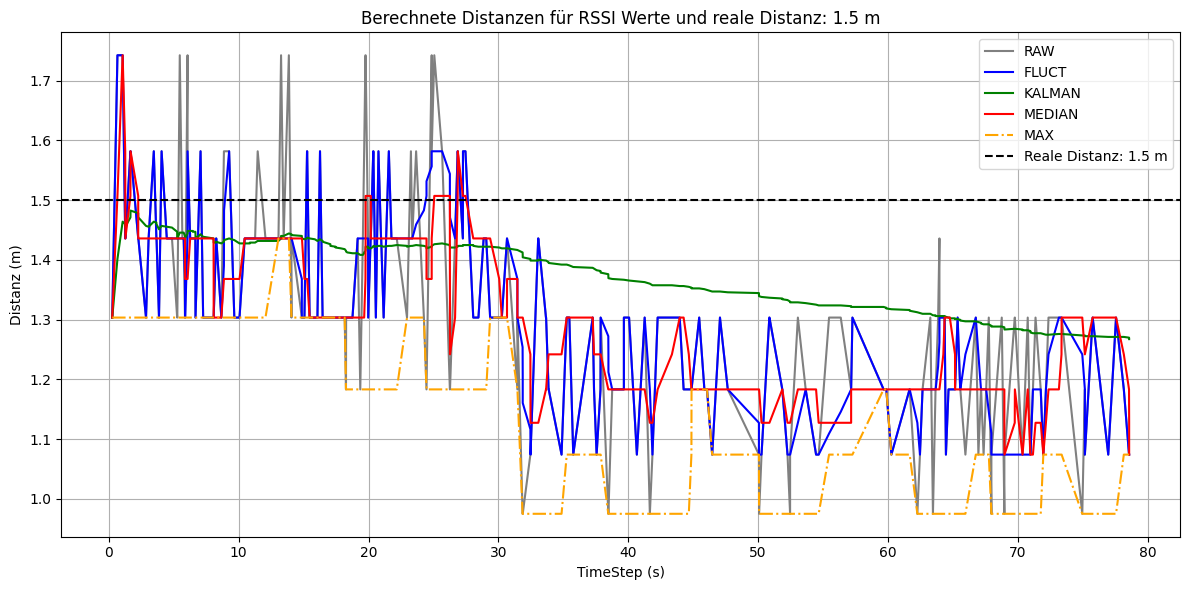

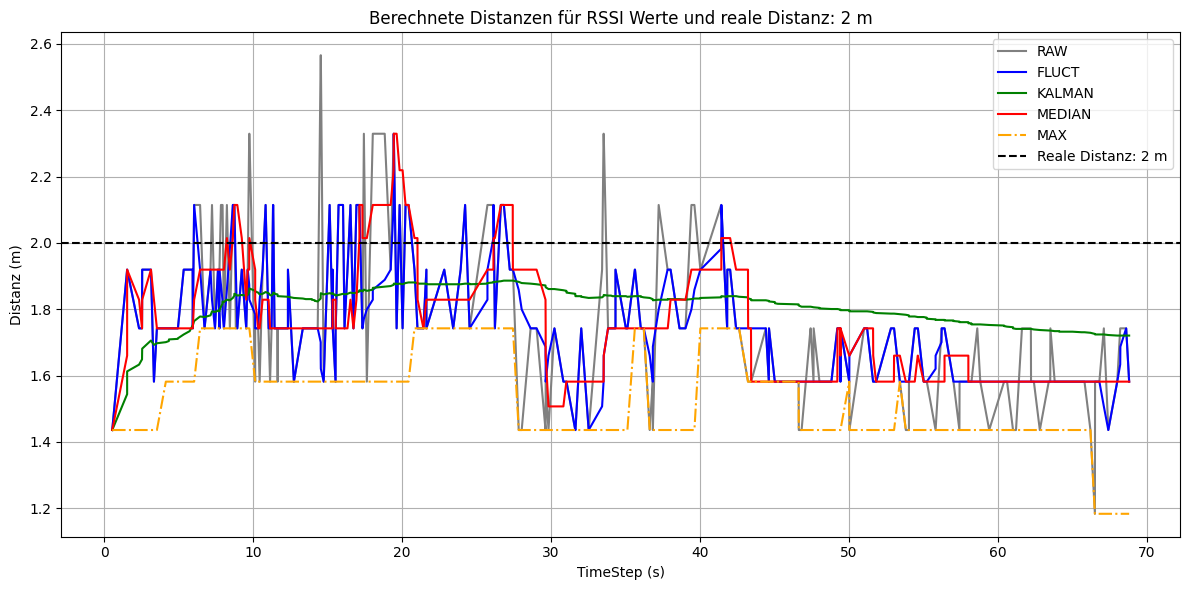

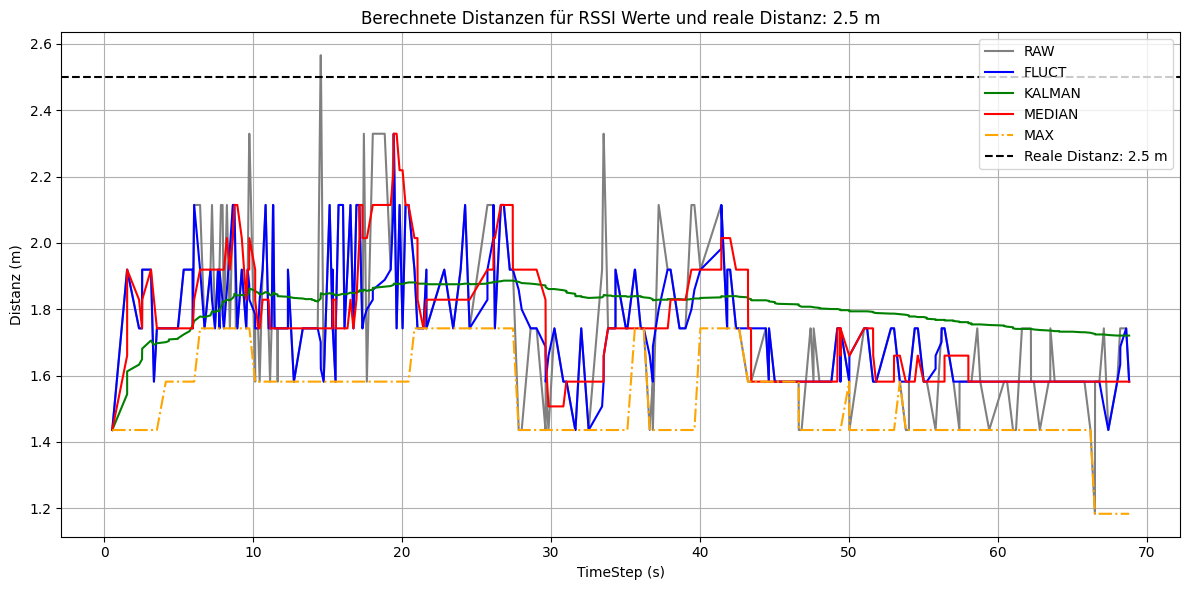

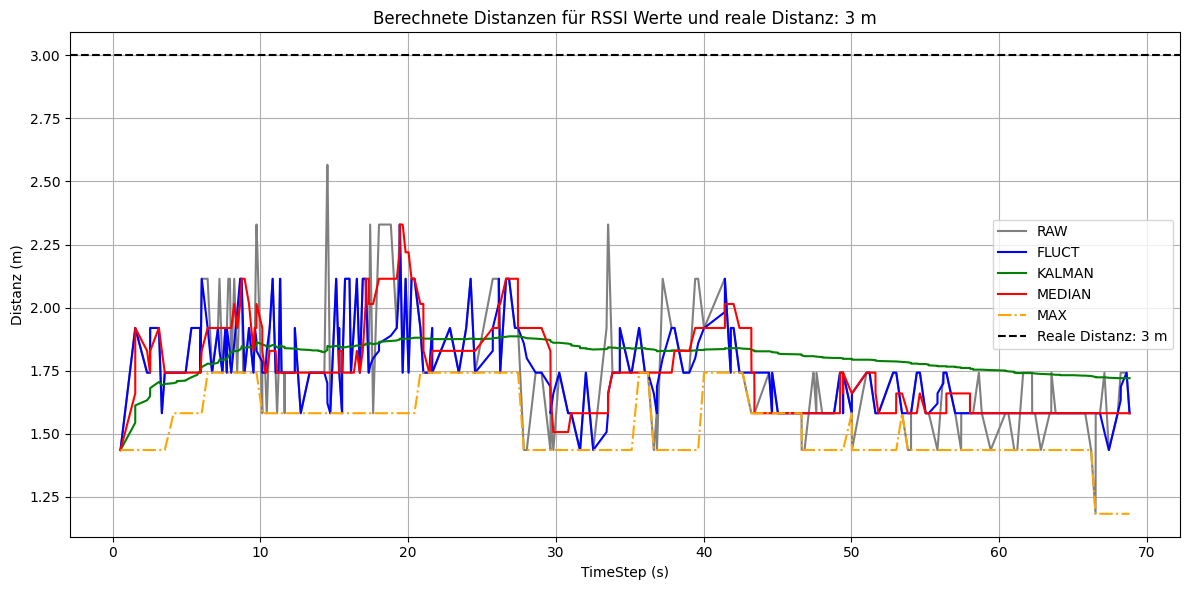

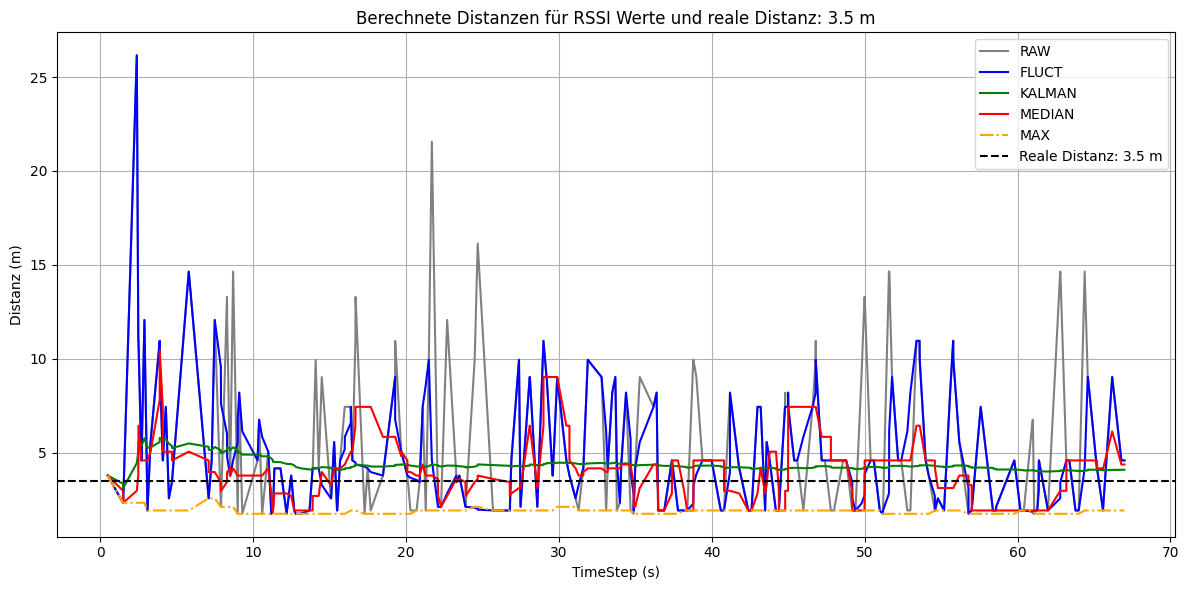

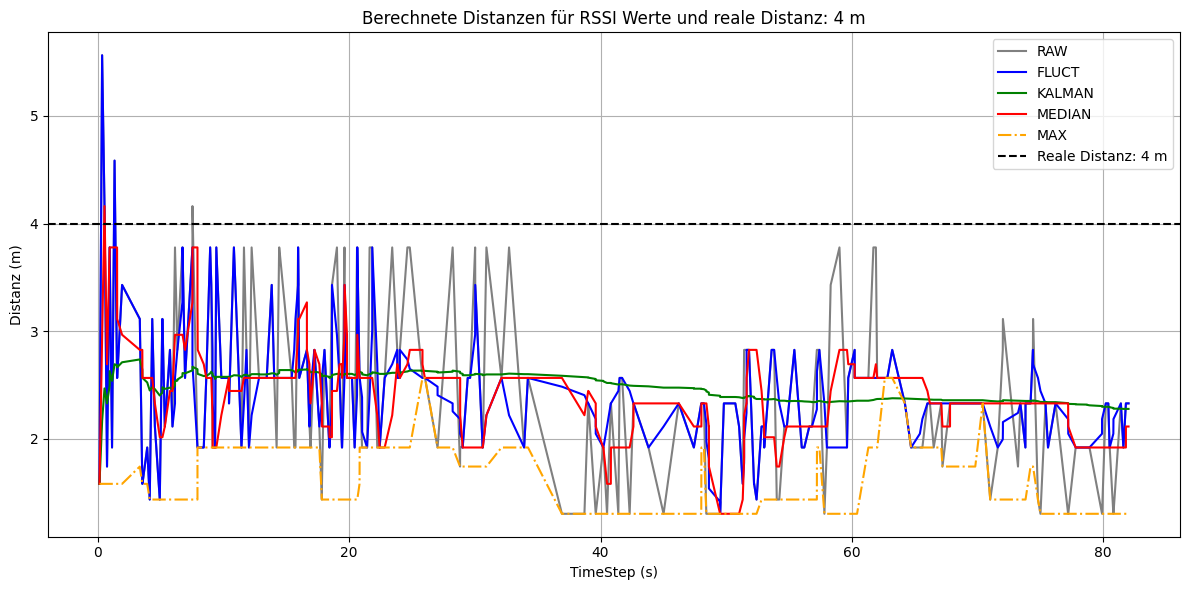

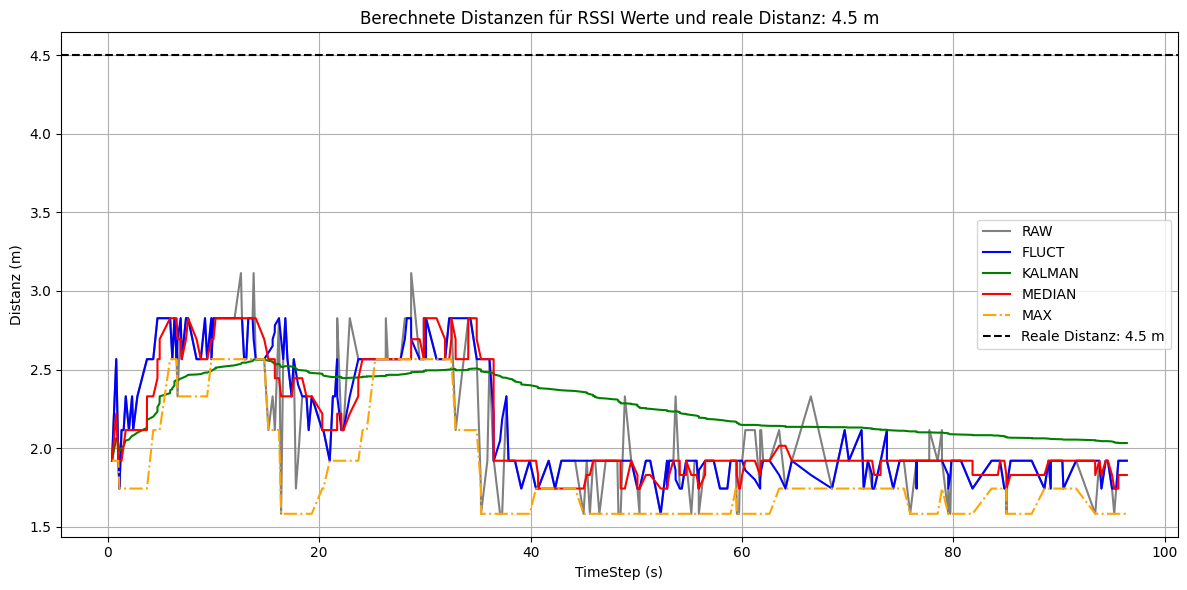

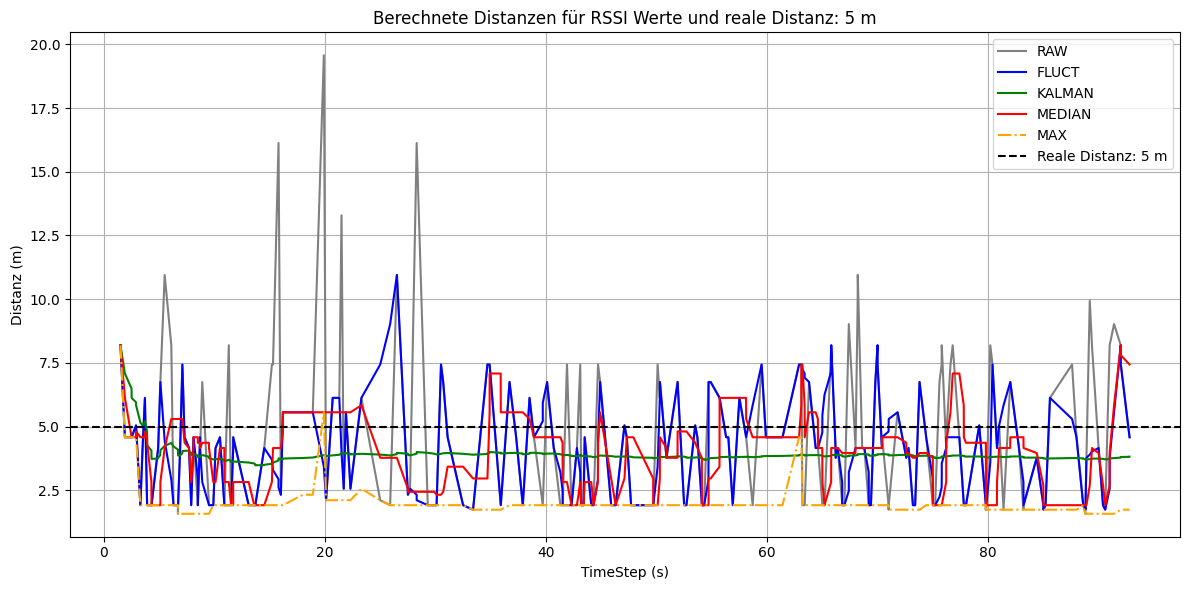

In [ ]:
# Parameter
rssi_one_meter = -45.26  # RSSI-Wert bei 1 Meter (dBm), anpassen
disturbance_level = 2.38  # Störungseffekt (Wert n, anpassen)
sigma_shadow = 14.1 # Shadowing Effekt

# Anzahl der Filter (RAW, FLUCT, KALMAN, MEDIAN, MAX)
num_filters = 5

# Variablen, um die berechneten Distanzen zu speichern
distances_estimated_all = {}
real_distances = []

for i, dist in enumerate(distances):
    real_distances.append(dist)

    # Spalten für die aktuelle Distanz extrahieren
    start_col = i * (num_filters + 1)  # Startspalte für diese Distanz
    cols = df.columns[start_col : start_col + (num_filters + 1)]  # Zeitsäule + Filterspalten

    # Sub-DataFrame erstellen
    dist_df = df[cols].rename(columns={
        cols[0]: 'TimeStep',
        cols[1]: 'RAW',
        cols[2]: 'FLUCT',
        cols[3]: 'KALMAN',
        cols[4]: 'MEDIAN',
        cols[5]: 'MAX'
    })

    # NaN-Werte interpolieren
    dist_df = dist_df.interpolate()

    # Berechnete Distanzen aus RSSI-Werten für jeden Filter
    distances_estimated = {
        'RAW': [],
        'FLUCT': [],
        'KALMAN': [],
        'MEDIAN': [],
        'MAX': []
    }

    # Berechnung der Distanzen für jedes Filter
    for filter_name in distances_estimated.keys():
        for rssi in dist_df[filter_name]:
            distance_est = logarithmic_distance_path_loss(rssi, rssi_one_meter, disturbance_level, sigma_shadow)
            distances_estimated[filter_name].append(distance_est)

    # Speichern der berechneten Distanzen für diese Distanz
    distances_estimated_all[dist] = distances_estimated

    # Plot für die aktuellen Distanzen erstellen
    plt.figure(figsize=(12, 6))

    # Plot der geschätzten Distanzen basierend auf den verschiedenen Filtern
    plt.plot(dist_df['TimeStep'], distances_estimated['RAW'], label='RAW', color='gray', linestyle='-')
    plt.plot(dist_df['TimeStep'], distances_estimated['FLUCT'], label='FLUCT', color='blue', linestyle='-')
    plt.plot(dist_df['TimeStep'], distances_estimated['KALMAN'], label='KALMAN', color='green', linestyle='-')
    plt.plot(dist_df['TimeStep'], distances_estimated['MEDIAN'], label='MEDIAN', color='red', linestyle='-')
    plt.plot(dist_df['TimeStep'], distances_estimated['MAX'], label='MAX', color='orange', linestyle='-.')

    # Realen Distanz als Referenz einzeichnen
    plt.axhline(y=dist, color='black', linestyle='--', label=f'Reale Distanz: {dist} m')

    # Achsenbeschriftungen und Titel
    plt.ylabel('Distanz (m)')
    plt.xlabel('TimeStep (s)')
    plt.title(f'Berechnete Distanzen für RSSI Werte und reale Distanz: {dist} m')
    plt.legend()
    plt.grid()
    plt.tight_layout()

    # Diagramm anzeigen
    plt.show()


# 3.2 Fehlerplot als kumulative Verteilungsfunktion (CDF)

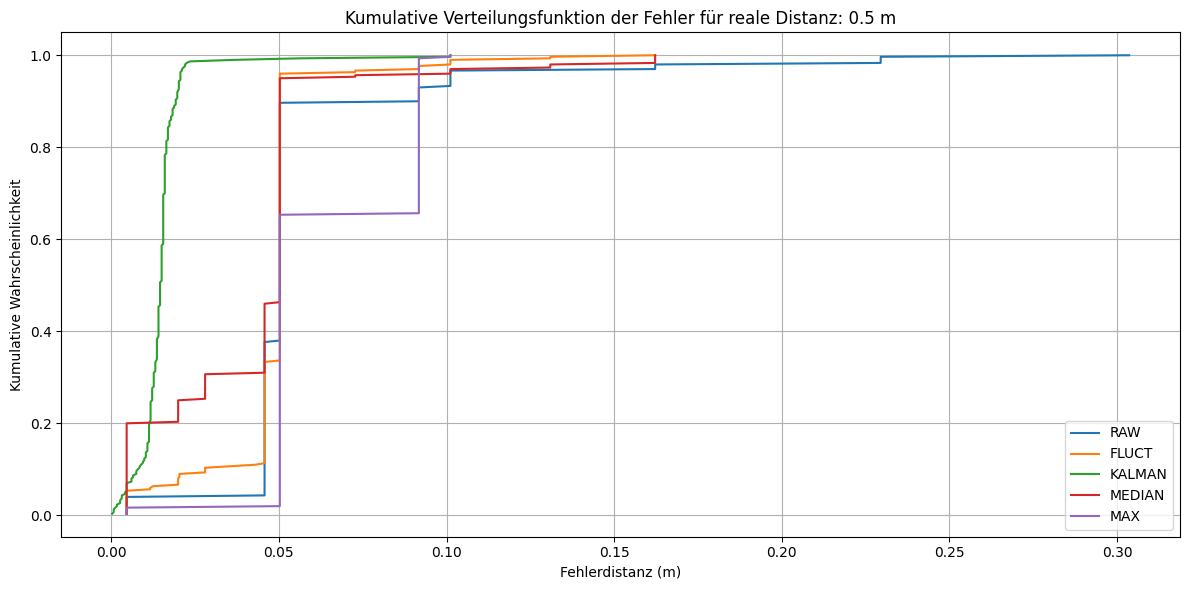

Fehler für 0.5 Meter:
  RAW: 50% - 0.05m, 75% - 0.05m, 95% - 0.10m
  FLUCT: 50% - 0.05m, 75% - 0.05m, 95% - 0.05m
  KALMAN: 50% - 0.01m, 75% - 0.02m, 95% - 0.02m
  MEDIAN: 50% - 0.05m, 75% - 0.05m, 95% - 0.05m
  MAX: 50% - 0.05m, 75% - 0.09m, 95% - 0.09m


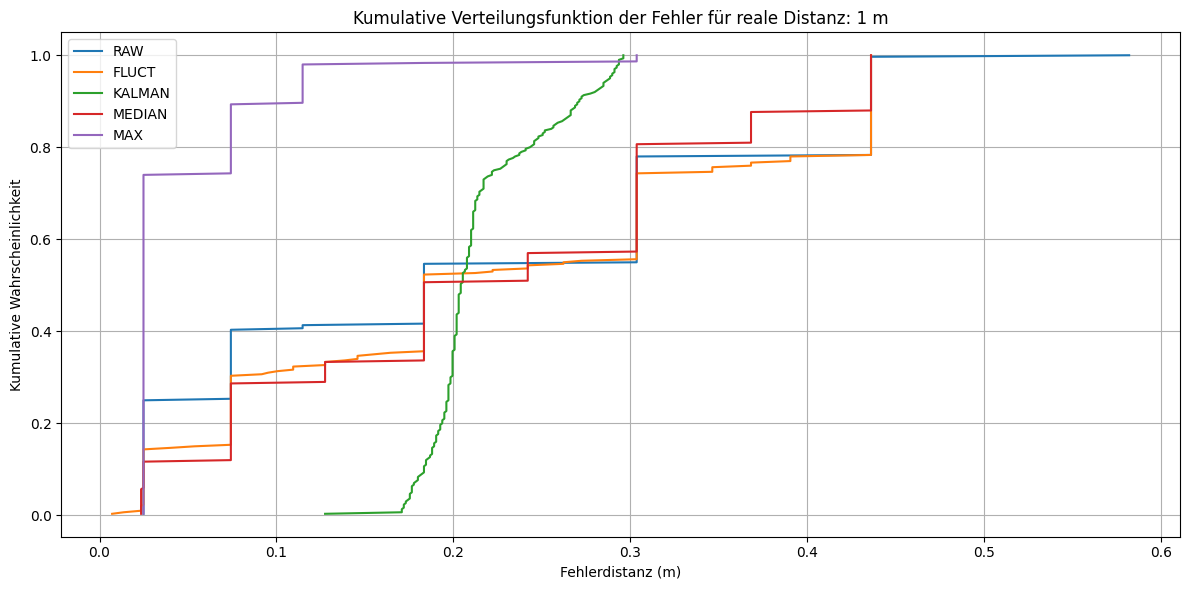

Fehler für 1 Meter:
  RAW: 50% - 0.18m, 75% - 0.30m, 95% - 0.44m
  FLUCT: 50% - 0.18m, 75% - 0.35m, 95% - 0.44m
  KALMAN: 50% - 0.20m, 75% - 0.22m, 95% - 0.29m
  MEDIAN: 50% - 0.18m, 75% - 0.30m, 95% - 0.44m
  MAX: 50% - 0.02m, 75% - 0.07m, 95% - 0.11m


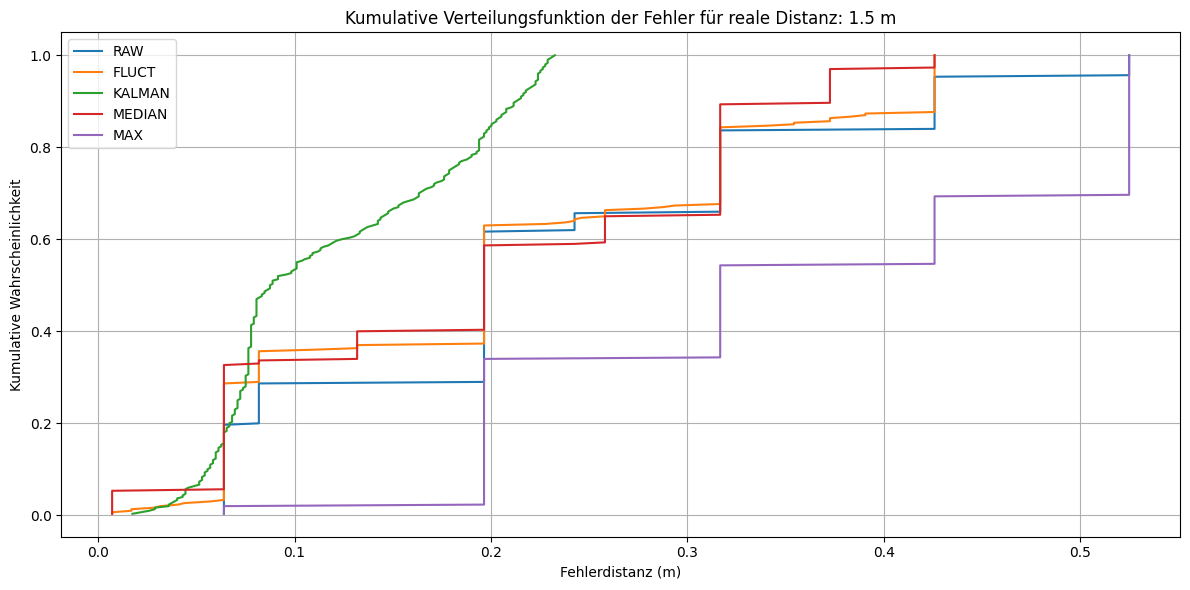

Fehler für 1.5 Meter:
  RAW: 50% - 0.20m, 75% - 0.32m, 95% - 0.43m
  FLUCT: 50% - 0.20m, 75% - 0.32m, 95% - 0.43m
  KALMAN: 50% - 0.09m, 75% - 0.18m, 95% - 0.22m
  MEDIAN: 50% - 0.20m, 75% - 0.32m, 95% - 0.37m
  MAX: 50% - 0.32m, 75% - 0.52m, 95% - 0.52m


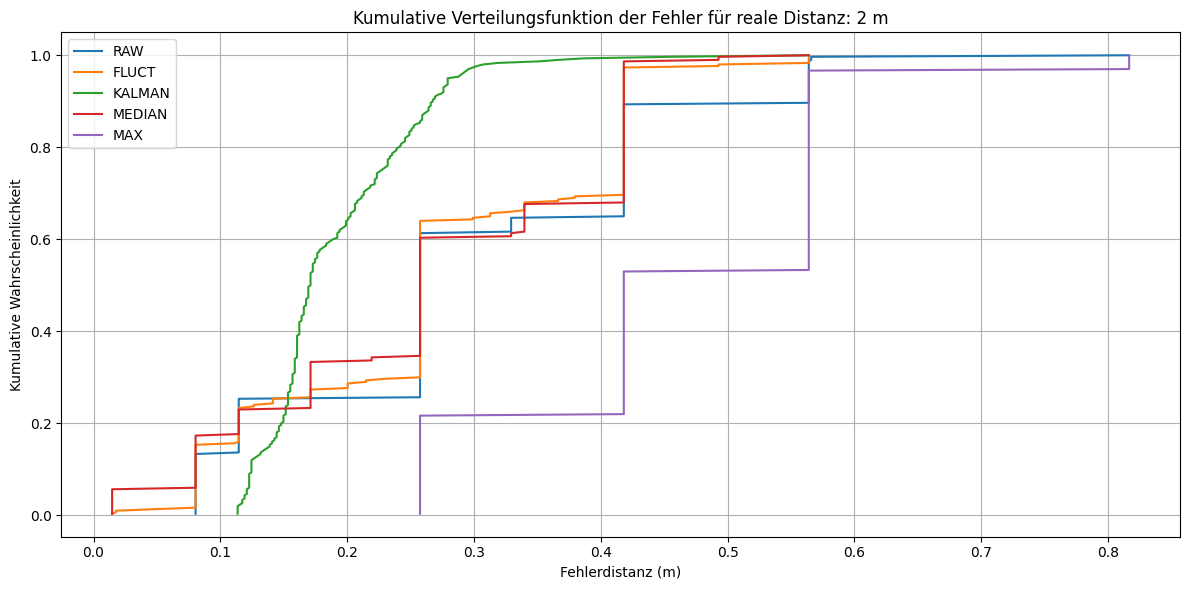

Fehler für 2 Meter:
  RAW: 50% - 0.26m, 75% - 0.42m, 95% - 0.56m
  FLUCT: 50% - 0.26m, 75% - 0.42m, 95% - 0.42m
  KALMAN: 50% - 0.17m, 75% - 0.23m, 95% - 0.28m
  MEDIAN: 50% - 0.26m, 75% - 0.42m, 95% - 0.42m
  MAX: 50% - 0.42m, 75% - 0.56m, 95% - 0.56m


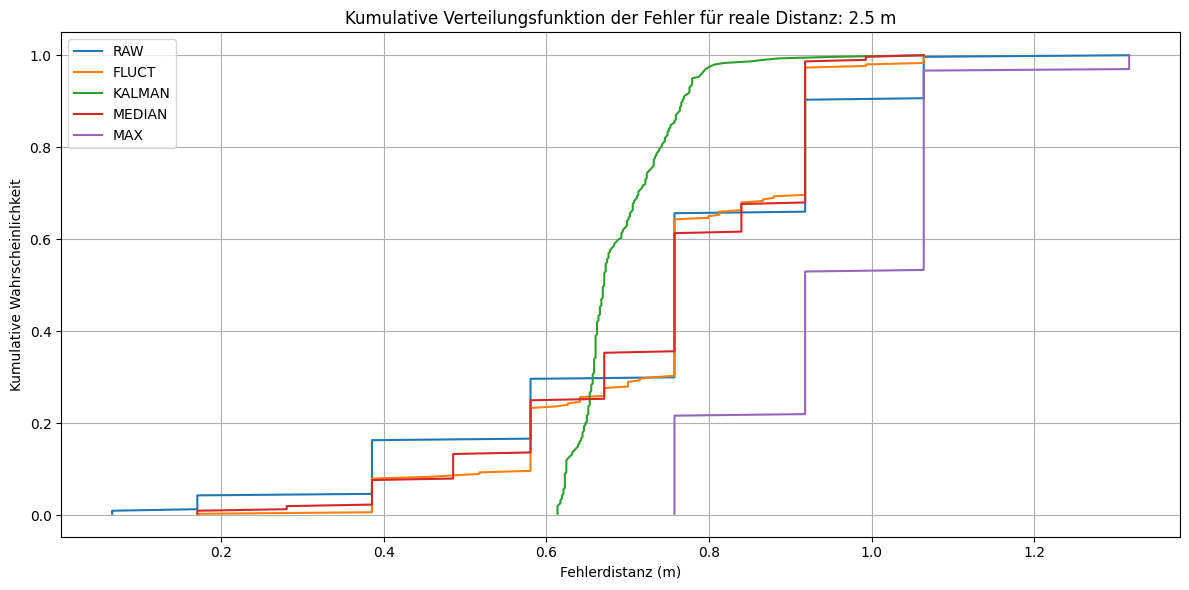

Fehler für 2.5 Meter:
  RAW: 50% - 0.76m, 75% - 0.92m, 95% - 1.06m
  FLUCT: 50% - 0.76m, 75% - 0.92m, 95% - 0.92m
  KALMAN: 50% - 0.67m, 75% - 0.73m, 95% - 0.78m
  MEDIAN: 50% - 0.76m, 75% - 0.92m, 95% - 0.92m
  MAX: 50% - 0.92m, 75% - 1.06m, 95% - 1.06m


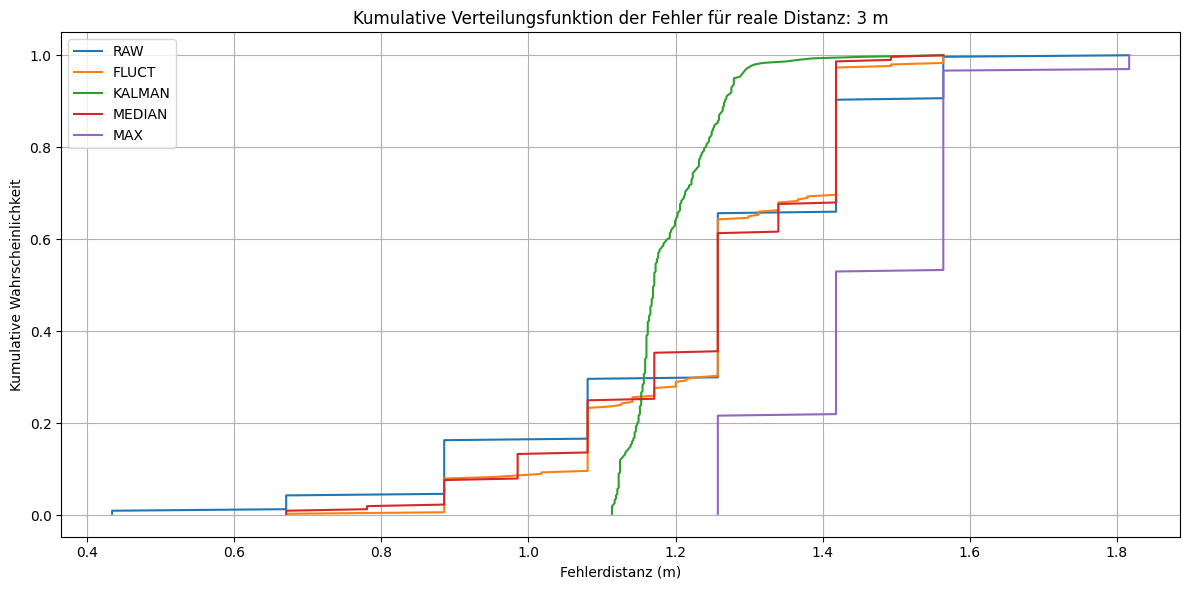

Fehler für 3 Meter:
  RAW: 50% - 1.26m, 75% - 1.42m, 95% - 1.56m
  FLUCT: 50% - 1.26m, 75% - 1.42m, 95% - 1.42m
  KALMAN: 50% - 1.17m, 75% - 1.23m, 95% - 1.28m
  MEDIAN: 50% - 1.26m, 75% - 1.42m, 95% - 1.42m
  MAX: 50% - 1.42m, 75% - 1.56m, 95% - 1.56m


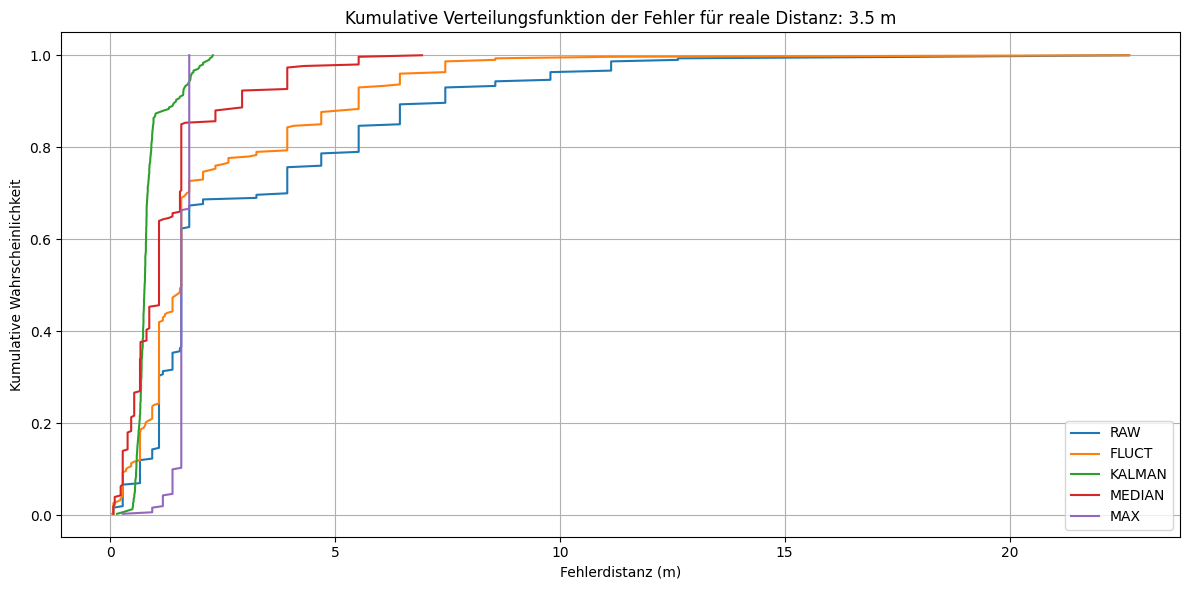

Fehler für 3.5 Meter:
  RAW: 50% - 1.58m, 75% - 3.94m, 95% - 9.79m
  FLUCT: 50% - 1.58m, 75% - 2.23m, 95% - 6.44m
  KALMAN: 50% - 0.77m, 75% - 0.87m, 95% - 1.79m
  MEDIAN: 50% - 1.09m, 75% - 1.58m, 95% - 3.94m
  MAX: 50% - 1.58m, 75% - 1.76m, 95% - 1.76m


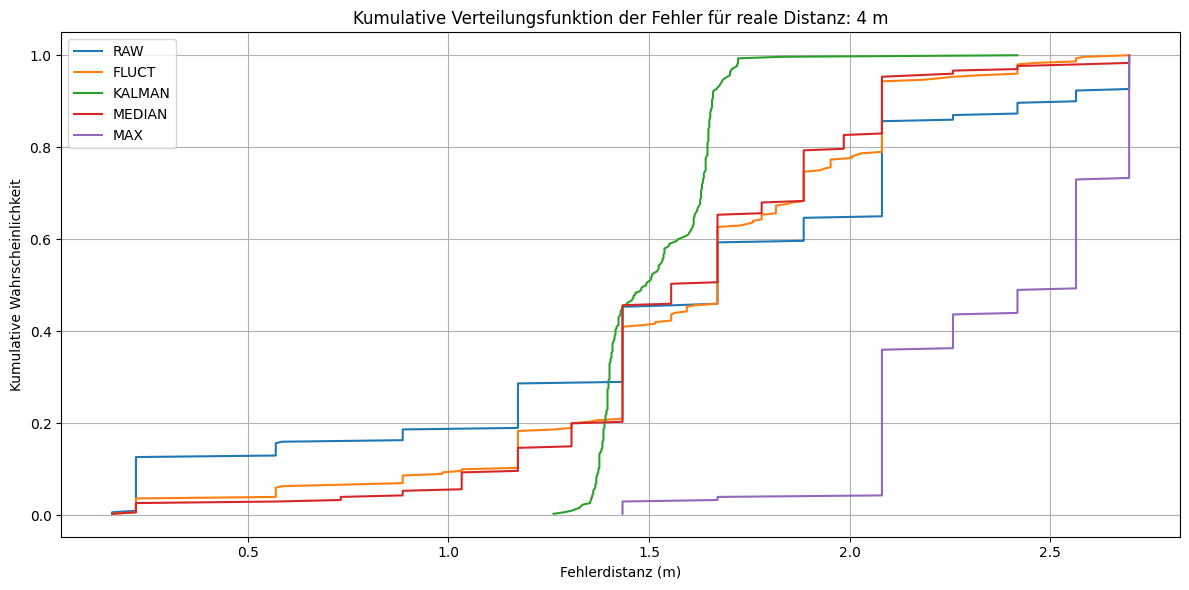

Fehler für 4 Meter:
  RAW: 50% - 1.67m, 75% - 2.08m, 95% - 2.70m
  FLUCT: 50% - 1.67m, 75% - 1.93m, 95% - 2.23m
  KALMAN: 50% - 1.49m, 75% - 1.64m, 95% - 1.69m
  MEDIAN: 50% - 1.56m, 75% - 1.89m, 95% - 2.08m
  MAX: 50% - 2.56m, 75% - 2.70m, 95% - 2.70m


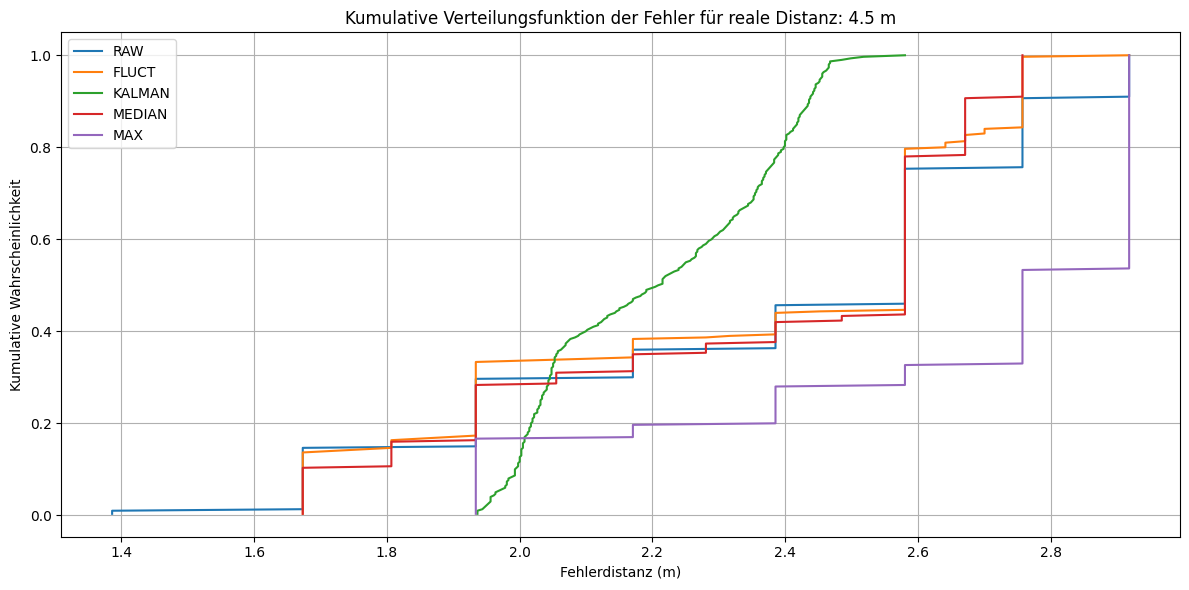

Fehler für 4.5 Meter:
  RAW: 50% - 2.58m, 75% - 2.58m, 95% - 2.92m
  FLUCT: 50% - 2.58m, 75% - 2.58m, 95% - 2.76m
  KALMAN: 50% - 2.21m, 75% - 2.37m, 95% - 2.45m
  MEDIAN: 50% - 2.58m, 75% - 2.58m, 95% - 2.76m
  MAX: 50% - 2.76m, 75% - 2.92m, 95% - 2.92m


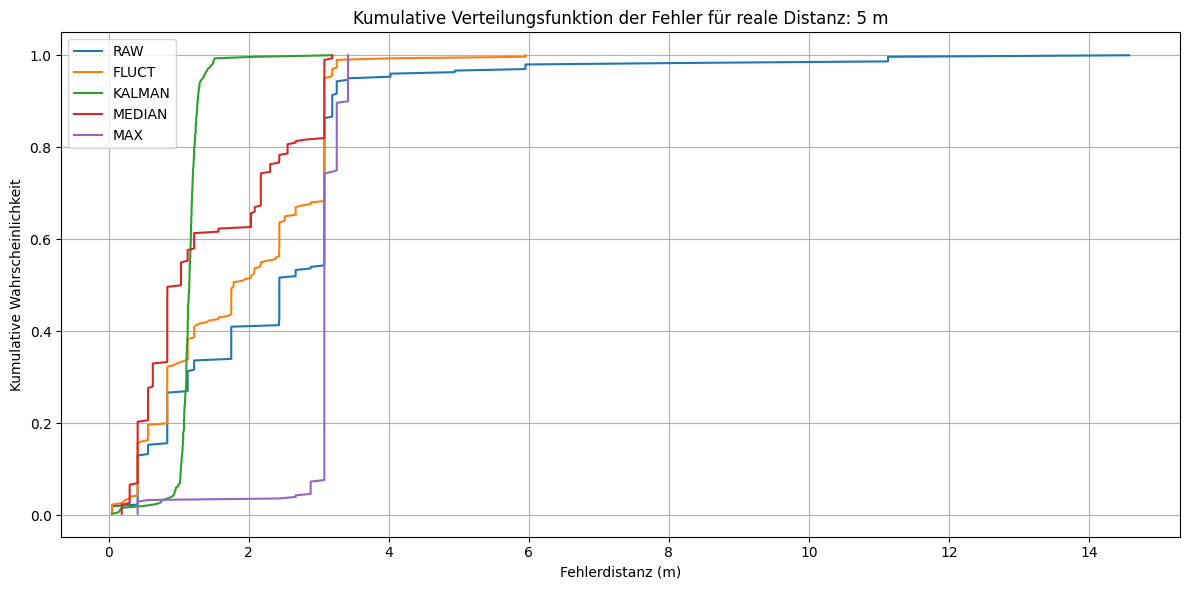

Fehler für 5 Meter:
  RAW: 50% - 2.44m, 75% - 3.08m, 95% - 3.45m
  FLUCT: 50% - 1.78m, 75% - 3.08m, 95% - 3.09m
  KALMAN: 50% - 1.15m, 75% - 1.21m, 95% - 1.35m
  MEDIAN: 50% - 1.03m, 75% - 2.31m, 95% - 3.08m
  MAX: 50% - 3.08m, 75% - 3.26m, 95% - 3.42m


In [ ]:
# Fehler-CDF für jede reale Distanz erstellen
for real_distance, distances_estimated in distances_estimated_all.items():
    plt.figure(figsize=(12, 6))

    percentiles = {}

    for filter_name, estimated_distances in distances_estimated.items():
        # Fehler berechnen
        errors = np.abs(np.array(estimated_distances) - real_distance)

        # Fehler sortieren
        sorted_errors = np.sort(errors)

        # CDF-Werte berechnen
        cdf = np.arange(1, len(sorted_errors) + 1) / len(sorted_errors)

        # Plotten der CDF
        plt.plot(sorted_errors, cdf, label=f'{filter_name}', linestyle='-')

        # Berechnung der spezifischen Perzentilwerte
        percentiles[filter_name] = {
            "50%": np.percentile(sorted_errors, 50),
            "75%": np.percentile(sorted_errors, 75),
            "95%": np.percentile(sorted_errors, 95)
        }

    # Achsenbeschriftungen und Titel
    plt.xlabel('Fehlerdistanz (m)')
    plt.ylabel('Kumulative Wahrscheinlichkeit')
    plt.title(f'Kumulative Verteilungsfunktion der Fehler für reale Distanz: {real_distance} m')
    plt.legend()
    plt.grid()
    plt.tight_layout()

    # Diagramm anzeigen
    plt.show()

    # Ausgabe der Perzentilwerte
    print(f"Fehler für {real_distance} Meter:")
    for filter_name, perc_values in percentiles.items():
        print(f"  {filter_name}: 50% - {perc_values['50%']:.2f}m, 75% - {perc_values['75%']:.2f}m, 95% - {perc_values['95%']:.2f}m")


# 4. Einfluss des Körpers auf den RSSI

In [55]:
# Datei aus Google Drive laden
file_name_2 = '/content/drive/MyDrive/Colab Notebooks/Messung29.01-body.xlsx'

[2]


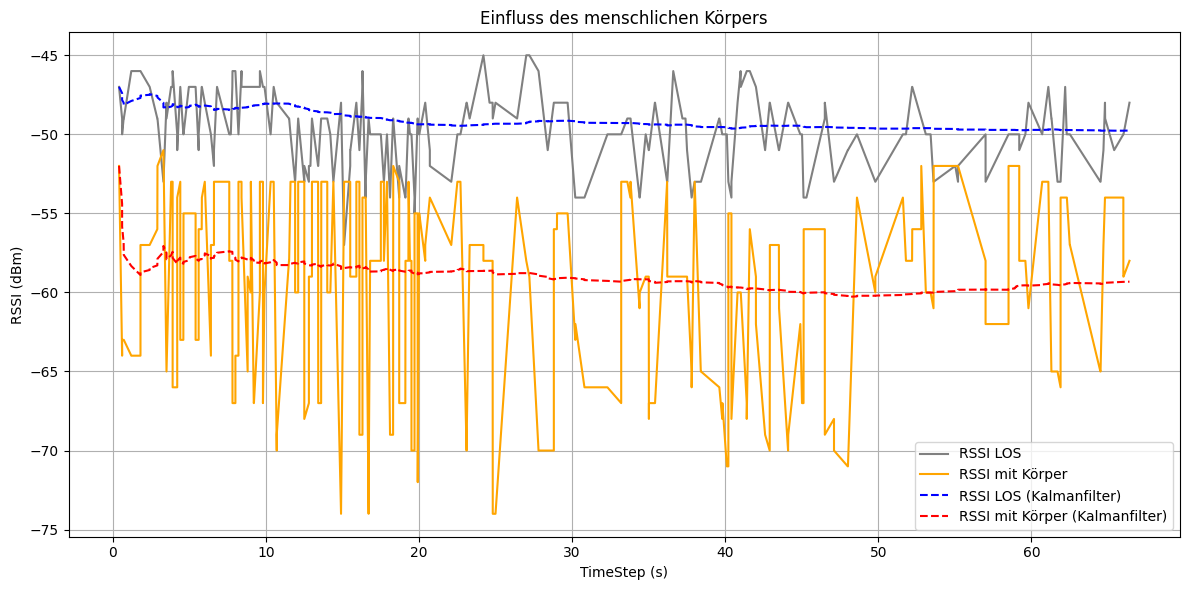

In [58]:
# Excel-Datei einlesen
df = pd.read_excel(file_name_2, header=1)  # Die zweite Zeile enthält die Spaltenüberschriften
distances = pd.read_excel(file_name_2, header=None).iloc[0].dropna().unique()  # Die erste Zeile enthält die Distanzen

num_cols = 5  # Anzahl der Spalten pro Distanz

print(distances)

for i, dist in enumerate(distances):
    # Spalten für die aktuelle Distanz extrahieren
    start_col = i * (num_cols)  # Startspalte für diese Distanz
    cols = df.columns[start_col : start_col + (num_cols)]  # Zeitsäule + Filterspalten

    # Sub-DataFrame erstellen
    dist_df = df[cols].rename(columns={
        cols[0]: 'TimeStep',
        cols[1]: 'RAW_los',
        cols[2]: 'KALMAN_los',
        cols[3]: 'RAW_body',
        cols[4]: 'KALMAN_body'
    })

    # NaN-Werte interpolieren
    dist_df = dist_df.interpolate()

    # Graph 2
    plt.figure(figsize=(12, 6))
    plt.plot(dist_df['TimeStep'], dist_df['RAW_los'], label='RSSI LOS', color='gray', linestyle='-')
    plt.plot(dist_df['TimeStep'], dist_df['RAW_body'], label='RSSI mit Körper', color='orange', linestyle='-')
    plt.plot(dist_df['TimeStep'], dist_df['KALMAN_los'], label='RSSI LOS (Kalmanfilter)', color='blue', linestyle='--')
    plt.plot(dist_df['TimeStep'], dist_df['KALMAN_body'], label='RSSI mit Körper (Kalmanfilter)', color='red', linestyle='--')

    plt.ylabel('RSSI (dBm)')
    plt.xlabel('TimeStep (s)')
    plt.title('Einfluss des menschlichen Körpers')
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()


# 4.1 Einfluss der Rotation des Smartphones auf den RSSI

In [ ]:
# Datei aus Google Drive laden
file_name_3 = '/content/drive/MyDrive/Colab Notebooks/Messung29.01-rotation.xlsx'

In [ ]:
# Excel-Datei einlesen
df = pd.read_excel(file_name_3, header=1)  # Die zweite Zeile enthält die Spaltenüberschriften
distances = pd.read_excel(file_name_3, header=None).iloc[0].dropna().unique()  # Die erste Zeile enthält die Distanzen

num_cols = 6  # Anzahl der Spalten pr Distanz

print(distances)

for i, dist in enumerate(distances):
    # Spalten für die aktuelle Distanz extrahieren
    start_col = i * (num_cols)  # Startspalte für diese Distanz
    cols = df.columns[start_col : start_col + (num_cols)]  # Zeitsäule + Filterspalten

    # Sub-DataFrame erstellen
    dist_df = df[cols].rename(columns={
        cols[0]: 'TimeStep',
        cols[1]: 'RAW_los',
        cols[2]: 'KALMAN_los',
        cols[3]: 'RAW_rot',
        cols[4]: 'KALMAN_rot',
    })

    # NaN-Werte interpolieren
    dist_df = dist_df.interpolate()

    # Graph 1
    plt.figure(figsize=(12, 6))
    plt.plot(dist_df['TimeStep'], dist_df['KALMAN_los'], label='RSSI LOS (Kalmanfilter)', color='blue', linestyle='-')
    plt.plot(dist_df['TimeStep'], dist_df['KALMAN_rot'], label='RSSI mit rotation (Kalmanfilter)', color='green', linestyle='--')

    plt.ylabel('RSSI (dBm)')
    plt.xlabel('TimeStep (s)')
    plt.title('Einfluss von Rotation des Smartphones')
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()


# Einfluss auf den Winkel der Person zum Beacon

In [8]:
# Datei aus Google Drive laden
file_name_4 = '/content/drive/MyDrive/Colab Notebooks/Messung28.01-winkelvergleich.xlsx'

<Figure size 1200x600 with 0 Axes>

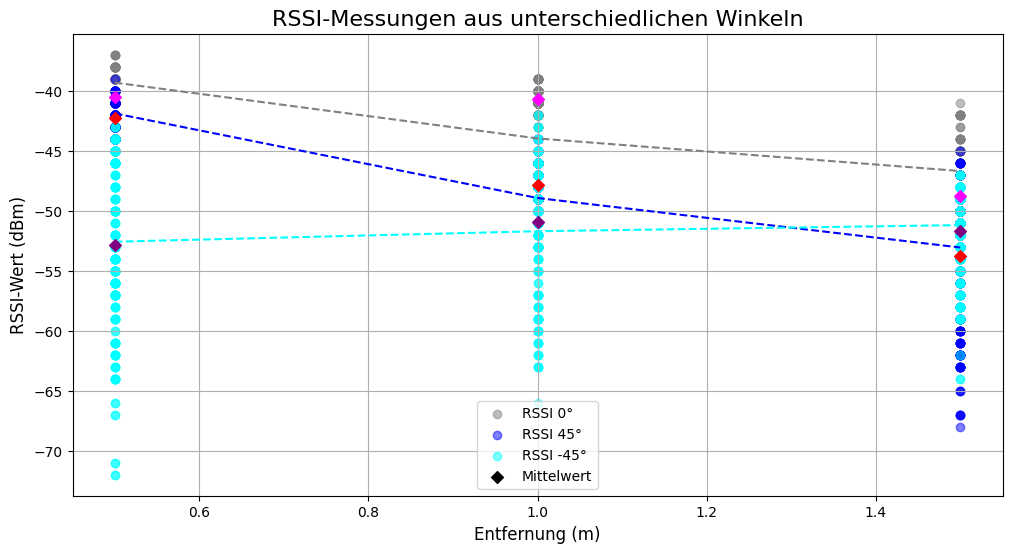

In [31]:
# Excel-Datei einlesen
df = pd.read_excel(file_name_4, header=1)
distances = pd.read_excel(file_name_4, header=None).iloc[0].dropna().unique()

num_col = 7
angles = ['RAW_0', 'RAW_45', 'RAW_-45']
line_colors = ['gray', 'blue', 'cyan']
mean_colors = ['magenta', 'red', 'purple']

# Graphen erstellen
plt.figure(figsize=(12, 6))

# Distance Path-Loss Model
def rssi_model(distance, n, a):
    return -10 * n * np.log10(distance) + a

# Graphen erstellen
plt.figure(figsize=(12, 6))


for index, angle in enumerate(angles):

  mean_rssi_per_distance = {}

  for i, dist in enumerate(distances):
      # Spalten für die aktuelle Distanz extrahieren
      start_col = i * (num_col)  # Startspalte für diese Distanz
      cols = df.columns[start_col : start_col + num_col]

      # Sub-DataFrame erstellen
      dist_df = df[cols].rename(columns={
          cols[0]: 'TimeStep',
          cols[1]: 'RAW_0',
          cols[2]: 'KALMAN_0',
          cols[3]: 'RAW_-45',
          cols[4]: 'KALMAN_-45',
          cols[5]: 'RAW_45',
          cols[6]: 'KALMAN_45'
      })

      # NaN-Werte interpolieren
      dist_df = dist_df.interpolate()

      # Mittelwert der RSSI-Werte für jede Entfernung berechnen
      mean_rssi_per_distance[dist] = dist_df[angle].mean()

      # Einzelne RSSI-Werte für diese Distanz darstellen
      angle_label = angle.split('_')[-1] + '°'
      plt.scatter([dist] * len(dist_df), dist_df[angle], color=line_colors[index], alpha=0.5, label=f'RSSI {angle_label}' if i == 0 else "")

  # Curve-Fit durchführen
  distances = list(mean_rssi_per_distance.keys())
  mean_rssi_values = list(mean_rssi_per_distance.values())

  # DPL-Model
  popt, pcov = curve_fit(rssi_model, distances, mean_rssi_values)
  n, a = popt

  # Fit-Daten berechnen
  fitted_rssi = rssi_model(np.array(distances), n, a)

  # Mittelwert als Punkte für jede Entfernung zeichnen
  plt.scatter(distances, mean_rssi_values,
              color=mean_colors[index], marker='D', zorder=5)

  # Angepasste Kurve hinzufügen
  plt.plot(distances, fitted_rssi,
          color=line_colors[index], linestyle='--')

# Titel und Achsenbeschriftungen hinzufügen
plt.title(f"RSSI-Messungen aus unterschiedlichen Winkeln", fontsize=16)

plt.xlabel("Entfernung (m)", fontsize=12)
plt.ylabel("RSSI-Wert (dBm)", fontsize=12)

# Legende hinzufügen
plt.scatter([], [], color='black', marker='D', label='Mittelwert')
plt.legend()

# Raster aktivieren
plt.grid(True)

# Plot anzeigen
plt.show()

# 5.0 IPS Raum-Darstellung

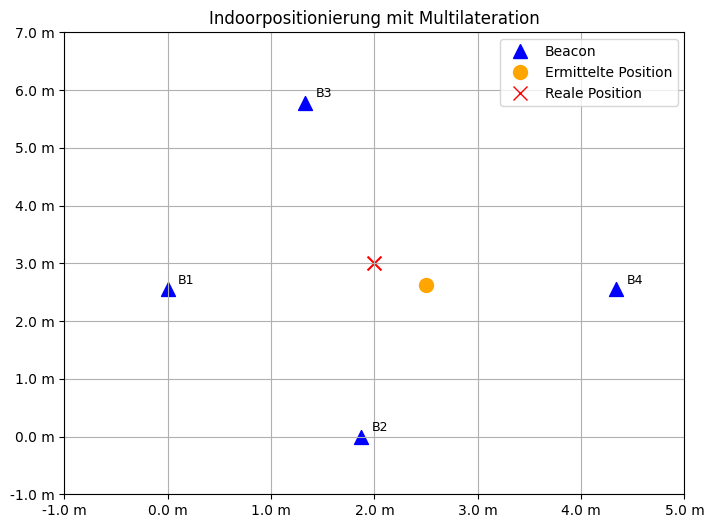

In [23]:
# Beispiel-Koordinaten
coordinates = [
    {'x': 0.00, 'y': 2.55, 'label': 'B1', 'group': 1},
    {'x': 1.87, 'y': 0.00, 'label': 'B2', 'group': 1},
    {'x': 1.33, 'y': 5.78, 'label': 'B3', 'group': 1},
    {'x': 4.34, 'y': 2.55, 'label': 'B4', 'group': 1},
    {'x': 2, 'y': 3, 'label': '', 'group': 3},
    {'x': 2.50, 'y': 2.62, 'label': '', 'group': 2},
]

# Symbole für Gruppen definieren
group_symbols = {
  1: '^',  # Beacon (Dreieck)
  2: 'o',  # User (Kreis)
  3: 'x',  # Referenz
}

# Farben für Gruppen definieren
group_colors = {
  1: 'blue',
  2: 'orange',
  3: 'red',
}

# Erstellen der Figur
plt.figure(figsize=(8, 6))

for coord in coordinates:
    x = coord['x']
    y = coord['y']
    label = coord['label']
    group = coord['group']

    # Symbol und Farbe basierend auf der Gruppe auswählen
    symbol = group_symbols.get(group, 'o')  # Standard: Kreis
    color = group_colors.get(group, 'black')  # Standard: Schwarz

    # Punkt plotten
    plt.scatter(x, y, label=label, marker=symbol, color=color, s=100)

    # Label als Text hinzufügen
    plt.text(x + 0.1, y + 0.1, label, fontsize=9)

# Achsenticks anpassen, um "m" hinzuzufügen
xticks = plt.xticks()[0]
yticks = plt.yticks()[0]
plt.xticks(xticks, [f"{tick} m" for tick in xticks])
plt.yticks(yticks, [f"{tick} m" for tick in yticks])

# Achsen und Titel
# plt.xlabel('X-Koordinate (Meter)')
# plt.ylabel('Y-Koordinate (Meter)')
plt.title('Indoorpositionierung mit Multilateration')

# Legende
handles = [
    plt.Line2D([0], [0], marker=group_symbols[1], color=group_colors[1], markersize=10, label='Beacon', linestyle='None'),
    plt.Line2D([0], [0], marker=group_symbols[2], color=group_colors[2], markersize=10, label='Ermittelte Position', linestyle='None'),
    plt.Line2D([0], [0], marker=group_symbols[3], color=group_colors[3], markersize=10, label='Reale Position', linestyle='None'),
]
plt.legend(handles=handles, loc='upper right')

# Graph anzeigen
plt.grid(True)
plt.show()
